# Análise Multivariada Universidade Federal de Roraima

## Discente: Rogério de Carvalho Cordovil
## Orientador: Professor Doutor Herbert Oliveira Rocha

Este notebook prepara a execução automática do experimento em **modo duplo**, permitindo rodar tanto:

- o **dataset controlado** em `dataset_cenarios/`, organizado em três subpastas:
  - `objeto_abandonado`
  - `furto_bicicleta`
  - `deteccao_violencia`
- quanto a **validação com datasets públicos**, utilizando:
  - `datasets/UCF_Crime/Anomaly-Videos`
  - `datasets/Avenue/testing_videos`

Os resultados são salvos por vídeo e também consolidados em tabelas e gráficos comparativos.


## 1. Importações e configuração dos caminhos do experimento

Este notebook foi ajustado para **reprodutibilidade**, utilizando uma pasta compartilhada no **Google Drive** em vez de caminhos locais fixos.

Antes de executar, organize no Drive uma estrutura semelhante a esta:

- `TCC_ECAI_2026/`
  - `dataset_cenarios/`
    - `objeto_abandonado/`
    - `furto_bicicleta/`
    - `deteccao_violencia/`
  - `datasets/`
    - `UCF_Crime/`
      - `Anomaly-Videos/`
    - `Avenue/`
      - `testing_videos/`
  - `modelos/`
    - `yolo26n.pt`
  - `resultados_multicenario/`

No Google Colab, o Drive será montado automaticamente. Em ambiente local, também é possível ajustar manualmente `PROJECT_ROOT`.

O parâmetro `MODO_EXECUCAO` controla a origem dos vídeos:

- `"cenarios"` → usa `dataset_cenarios/` (experimento principal)
- `"datasets"` → usa `UCF_Crime` + `Avenue` (validação científica)


In [28]:
import os
import glob
import random
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
!pip install ultralytics
from ultralytics import YOLO
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==========================================
# CONFIGURAÇÃO REPRODUTÍVEL DO EXPERIMENTO
# ==========================================

IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

DRIVE_PROJECT_FOLDER = "TCC_ECAI_2026"

PROJECT_ROOT = os.getenv(
    "PROJECT_ROOT",
    f"/content/drive/MyDrive/{DRIVE_PROJECT_FOLDER}" if IN_COLAB else os.path.abspath("./TCC_ECAI_2026")
)

# --------- Modo de execução ---------
# "cenarios"  -> usa dataset_cenarios (vídeos curados e organizados manualmente)
# "datasets"  -> usa datasets públicos UCF_Crime + Avenue
MODO_EXECUCAO = "datasets"

# --------- Desempenho ---------
FRAME_STRIDE = 2              # processa 1 a cada N frames
MAX_FRAMES_POR_VIDEO = None   # use um inteiro para limitar, ou None para processar todo o vídeo
SEED_EXPERIMENTO = 42
random.seed(SEED_EXPERIMENTO)
np.random.seed(SEED_EXPERIMENTO)

# --------- Caminhos ---------
CENARIOS_PATH = os.path.join(PROJECT_ROOT, "dataset_cenarios")
DATASETS_PATH = os.path.join(PROJECT_ROOT, "datasets")
UCF_PATH = os.path.join(DATASETS_PATH, "UCF_Crime", "Anomaly-Videos")
AVENUE_PATH = os.path.join(DATASETS_PATH, "Avenue", "testing_videos")
MODELO_PATH = os.path.join(PROJECT_ROOT, "modelos", "yolo26n.pt")

RESULTADOS_BASE = os.path.join(PROJECT_ROOT, "resultados_multicenario")
RESULTADOS_PATH = os.path.join(RESULTADOS_BASE, MODO_EXECUCAO)
os.makedirs(RESULTADOS_PATH, exist_ok=True)

CENARIOS_FIXOS = ["objeto_abandonado", "furto_bicicleta", "deteccao_violencia"]
MAPA_CENARIO_PASTA = {
    "objeto_abandonado": "objeto_abandonado",
    "furto_bicicleta": "furto_bicicleta",
    "deteccao_violencia": "deteccao_violencia"
}

EXTENSOES_VIDEO = ("*.avi", "*.mp4", "*.mov", "*.mkv")

def listar_videos(pasta):
    videos = []
    if not os.path.isdir(pasta):
        print(f"Aviso: pasta não encontrada: {pasta}")
        return videos
    for ext in EXTENSOES_VIDEO:
        videos.extend(glob.glob(os.path.join(pasta, ext)))
    return sorted(videos)

def selecionar_ucf(n=10):
    palavras = ["Fighting", "Robbery", "Assault", "Abuse"]
    arquivos = listar_videos(UCF_PATH)
    filtrados = [f for f in arquivos if any(p in os.path.basename(f) for p in palavras)]
    if len(filtrados) < n:
        print(f"Aviso: apenas {len(filtrados)} vídeos do UCF-Crime encontrados para as classes-alvo.")
    return sorted(filtrados)[:n]

def selecionar_avenue(n=20):
    arquivos = listar_videos(AVENUE_PATH)
    if len(arquivos) < n:
        print(f"Aviso: apenas {len(arquivos)} vídeos do Avenue disponíveis.")
    return sorted(arquivos)[:n]

def listar_videos_experimento(modo_execucao):
    videos_info = []

    if modo_execucao == "cenarios":
        for cenario in CENARIOS_FIXOS:
            pasta_cenario = os.path.join(CENARIOS_PATH, MAPA_CENARIO_PASTA.get(cenario, cenario))
            videos = listar_videos(pasta_cenario)
            for video_path in videos:
                videos_info.append({
                    "cenario_esperado": cenario,
                    "video_path": video_path,
                    "arquivo_video": os.path.basename(video_path),
                    "origem": "dataset_cenarios"
                })

    elif modo_execucao == "datasets":
        avenue_videos = selecionar_avenue(20)
        videos_cenarios = {
            "objeto_abandonado": avenue_videos[:10],
            "furto_bicicleta": avenue_videos[10:20],
            "deteccao_violencia": selecionar_ucf(10)
        }
        for cenario, videos in videos_cenarios.items():
            origem = "Avenue" if cenario != "deteccao_violencia" else "UCF_Crime"
            for video_path in videos:
                videos_info.append({
                    "cenario_esperado": cenario,
                    "video_path": video_path,
                    "arquivo_video": os.path.basename(video_path),
                    "origem": origem
                })
    else:
        raise ValueError("MODO_EXECUCAO deve ser 'cenarios' ou 'datasets'.")

    return videos_info

def coletar_metricas_sistema():
    proc = psutil.Process(os.getpid())
    ram_mb = proc.memory_info().rss / (1024 ** 2)

    gpu_mb = None
    try:
        import torch
        if torch.cuda.is_available():
            gpu_mb = torch.cuda.memory_allocated() / (1024 ** 2)
    except Exception:
        pass

    return {
        "ram_mb": round(float(ram_mb), 2),
        "gpu_mb": round(float(gpu_mb), 2) if gpu_mb is not None else np.nan
    }

videos_info = listar_videos_experimento(MODO_EXECUCAO)
df_videos = pd.DataFrame(videos_info)

if df_videos.empty:
    print("Nenhum vídeo encontrado. Verifique a estrutura do Google Drive e os caminhos configurados.")
else:
    print("Projeto:", PROJECT_ROOT)
    print("Modo de execução:", MODO_EXECUCAO)
    print("Dataset cenários:", CENARIOS_PATH)
    print("UCF-Crime:", UCF_PATH)
    print("Avenue:", AVENUE_PATH)
    print("Modelo:", MODELO_PATH)
    print("Resultados:", RESULTADOS_PATH)
    print("Frame stride:", FRAME_STRIDE)
    print(f"Total de vídeos encontrados: {len(df_videos)}")
    display(df_videos.head(20))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Projeto: /content/drive/MyDrive/TCC_ECAI_2026
Modo de execução: datasets
Dataset cenários: /content/drive/MyDrive/TCC_ECAI_2026/dataset_cenarios
UCF-Crime: /content/drive/MyDrive/TCC_ECAI_2026/datasets/UCF_Crime/Anomaly-Videos
Avenue: /content/drive/MyDrive/TCC_ECAI_2026/datasets/Avenue/testing_videos
Modelo: /content/drive/MyDrive/TCC_ECAI_2026/modelos/yolo26n.pt
Resultados: /content/drive/MyDrive/TCC_ECAI_2026/resultados_multicenario/datasets
Frame stride: 2
Total de vídeos encontrados: 30


,cenario_esperado,video_path,arquivo_video,origem
0,objeto_abandonado,/content/drive/MyDrive/TCC_ECAI_2026/datasets/...,01.avi,Avenue
1,objeto_abandonado,/content/drive/MyDrive/TCC_ECAI_2026/datasets/...,02.avi,Avenue
2,objeto_abandonado,/content/drive/MyDrive/TCC_ECAI_2026/datasets/...,03.avi,Avenue
3,objeto_abandonado,/content/drive/MyDrive/TCC_ECAI_2026/datasets/...,04.avi,Avenue
4,objeto_abandonado,/content/drive/MyDrive/TCC_ECAI_2026/datasets/...,05.avi,Avenue
5,objeto_abandonado,/content/drive/MyDrive/TCC_ECAI_2026/datasets/...,06.avi,Avenue
6,objeto_abandonado,/content/drive/MyDrive/TCC_ECAI_2026/datasets/...,07.avi,Avenue
7,objeto_abandonado,/content/drive/MyDrive/TCC_ECAI_2026/datasets/...,08.avi,Avenue
8,objeto_abandonado,/content/drive/MyDrive/TCC_ECAI_2026/datasets/...,09.avi,Avenue
9,objeto_abandonado,/content/drive/MyDrive/TCC_ECAI_2026/datasets/...,10.avi,Avenue


## 2. Carregamento do modelo YOLO

Carregue o modelo que será usado na detecção e no tracking.

In [29]:
modelo_yolo = YOLO(MODELO_PATH)
print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


## 4. Função para extrair detecções do YOLO

Converte a saída do modelo em uma lista padronizada de detecções.

In [30]:

def extrair_deteccoes(results, modelo_yolo):
    deteccoes = []

    for r in results:
        boxes = r.boxes

        if boxes is None or boxes.id is None:
            continue

        ids = boxes.id.cpu().numpy().astype(int)
        classes = boxes.cls.cpu().numpy().astype(int)
        coords = boxes.xyxy.cpu().numpy()
        confs = boxes.conf.cpu().numpy() if boxes.conf is not None else np.ones(len(ids), dtype=float)

        for box, obj_id, cls_id, conf in zip(coords, ids, classes, confs):
            x1, y1, x2, y2 = box
            centro_x = (x1 + x2) / 2
            centro_y = (y1 + y2) / 2
            largura = x2 - x1
            altura = y2 - y1

            deteccoes.append({
                "id": int(obj_id),
                "classe": modelo_yolo.names[int(cls_id)],
                "bbox": [float(centro_x), float(centro_y), float(largura), float(altura)],
                "confianca": float(conf)
            })

    return deteccoes


## 5. Funções independentes por cenário

O processamento foi organizado em **três funções independentes**, cada uma com seu conjunto de regras internas:

1. `objeto_abandonado`
2. `furto_bicicleta`
3. `deteccao_violencia`

In [31]:

CONFIG_CENARIOS = {
    "objeto_abandonado": {
        "classes_objeto": {"backpack", "handbag", "suitcase", "bag"},
        "distancia_associacao": 120.0,
        "distancia_abandono": 180.0,
        "tempo_separacao": 12.0,
        "tempo_abandono": 30.0,
        "velocidade_baixa": 2.0,
        "velocidade_saida": 12.0,
        "limite_alta_circulacao": 6,
        "std_conf_max_estavel": 0.08
    },
    "furto_bicicleta": {
        "classe_bicicleta": "bicycle",
        "distancia_interacao": 100.0,
        "tempo_interacao": 6.0,
        "tempo_permanencia": 18.0,
        "tentativas_minimas": 3,
        "delta_velocidade_saida": 3.0,
        "entropia_janela": 50,
        "entropia_sigma": 1.5,
        "entropia_min_amostras": 20,
        "entropia_pre_interacao": 0.55,
        "prob_prior_furto": 0.05,
        "prob_min": 0.01,
        "prob_max": 0.995,
        "lr_evidencias": {
            "manipulacao_prolongada": 2.8,
            "tentativa_repetida": 2.2,
            "ferramenta_suspeita": 1.4,
            "permanencia_anormal": 1.9,
            "sem_associacao_previa": 1.8,
            "velocidade_anomala_max": 3.0,
            "entropia_alta_max": 2.6,
            "acoplamento_proximidade_entropia": 4.8
        }
    },
    "deteccao_violencia": {
        "iou_luta": 0.40,
        "janela_curta": 8,
        "oscilacao_centroides": 22.0,
        "aceleracao_luta": 10.0,
        "aspect_ratio_vertical_min": 0.85,
        "aspect_ratio_horizontal_max": 0.75,
        "aspect_ratio_change_min": 0.45,
        "velocidade_quase_zero": 1.5,
        "proximidade_arma": 90.0,
        "iou_arma_empunhada": 0.05,
        "distancia_fluxo_centro": 120.0,
        "fuga_sigma": 2.0,
        "densidade_queda_z": 2.0
    }
}

CENARIOS_FIXOS = ["objeto_abandonado", "furto_bicicleta", "deteccao_violencia"]

def distancia_centros(bbox_a, bbox_b):
    a = np.array(bbox_a[:2], dtype=float)
    b = np.array(bbox_b[:2], dtype=float)
    return float(np.linalg.norm(a - b))

def iou_boxes(bbox_a, bbox_b):
    ax, ay, aw, ah = bbox_a[:4]
    bx, by, bw, bh = bbox_b[:4]

    ax1, ay1, ax2, ay2 = ax - aw / 2, ay - ah / 2, ax + aw / 2, ay + ah / 2
    bx1, by1, bx2, by2 = bx - bw / 2, by - bh / 2, bx + bw / 2, by + bh / 2

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, aw) * max(0.0, ah)
    area_b = max(0.0, bw) * max(0.0, bh)
    union = area_a + area_b - inter_area

    if union <= 0:
        return 0.0
    return float(inter_area / union)

def razao_aspecto(bbox):
    w = max(float(bbox[2]), 1e-6)
    h = max(float(bbox[3]), 1e-6)
    return float(h / w)

def classificar_risco(score):
    if score < 0.3:
        return "normal"
    elif score <= 0.6:
        return "suspeito/monitorar"
    return "alerta"

def atualizar_probabilidade_bayes(prob_anterior, likelihood_ratio, prob_min=0.01, prob_max=0.995):
    p = float(np.clip(prob_anterior, prob_min, prob_max))
    lr = max(float(likelihood_ratio), 1e-6)
    odds = p / (1.0 - p)
    odds_post = odds * lr
    p_post = odds_post / (1.0 + odds_post)
    return float(np.clip(p_post, prob_min, prob_max))

def combinar_probabilidades_bayesiana(probabilidades):
    probs = [min(max(float(p), 0.001), 0.999) for p in probabilidades if p is not None]
    if not probs:
        return 0.0
    odds = 1.0
    for p in probs:
        odds *= p / (1 - p)
    return float(odds / (1 + odds))

def calcular_zscore(valor_atual, historico_valores, min_amostras=20):
    if valor_atual is None or historico_valores is None:
        return 0.0
    if len(historico_valores) < min_amostras:
        return 0.0
    arr = np.asarray(historico_valores, dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) < min_amostras:
        return 0.0
    media = float(np.mean(arr))
    desvio = float(np.std(arr))
    if desvio < 1e-6:
        return 0.0
    return float((float(valor_atual) - media) / desvio)

def score_anomalia_z(z_score, limiar_severo=3.0):
    z_pos = max(0.0, float(z_score))
    return float(np.clip(z_pos / limiar_severo, 0.0, 1.0))

def inferir_area_sensivel(bbox, frame_shape):
    if frame_shape is None:
        return False
    altura, largura = frame_shape[:2]
    x, y = bbox[:2]
    regiao_superior = y < 0.22 * altura
    regiao_central = (0.35 * largura) <= x <= (0.65 * largura)
    regiao_lateral = x < 0.15 * largura or x > 0.85 * largura
    return bool(regiao_superior or (regiao_central and y < 0.35 * altura) or regiao_lateral)

def calcular_entropia_trajetoria(trajetoria):
    if len(trajetoria) < 5:
        return 0.0
    direcoes = []
    for i in range(1, len(trajetoria)):
        dx = trajetoria[i][0] - trajetoria[i - 1][0]
        dy = trajetoria[i][1] - trajetoria[i - 1][1]
        if abs(dx) < 1e-6 and abs(dy) < 1e-6:
            continue
        angulo = np.arctan2(dy, dx)
        direcoes.append(round(float(angulo), 1))
    if not direcoes:
        return 0.0
    return float(len(set(direcoes)) / len(direcoes))

def calcular_mudancas_direcao(trajetoria):
    if len(trajetoria) < 4:
        return 0
    sinais = []
    for i in range(1, len(trajetoria)):
        dx = trajetoria[i][0] - trajetoria[i - 1][0]
        dy = trajetoria[i][1] - trajetoria[i - 1][1]
        sinais.append((np.sign(dx), np.sign(dy)))
    mudancas = 0
    for i in range(1, len(sinais)):
        if sinais[i] != sinais[i - 1]:
            mudancas += 1
    return int(mudancas)

def estabilidade_confianca(historico_conf):
    vals = np.asarray([v for v in historico_conf if v is not None], dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) < 5:
        return np.nan
    return float(np.std(vals))

def densidade_pessoas_frame(pessoas, frame_shape):
    h, w = frame_shape[:2]
    area = max(float(h * w), 1.0)
    return float(len(pessoas) / area)

def calcular_centro_grupo(pessoas):
    if not pessoas:
        return None
    centros = [np.array(p["bbox"][:2], dtype=float) for p in pessoas]
    return np.mean(centros, axis=0)

def dispersao_media(pessoas, centro):
    if centro is None or not pessoas:
        return 0.0
    ds = [np.linalg.norm(np.array(p["bbox"][:2], dtype=float) - centro) for p in pessoas]
    return float(np.mean(ds))

def atualizar_historico_objetos(historico_objetos, deteccoes, tempo_atual):
    for d in deteccoes:
        obj_id = d.get("id")
        classe = d.get("classe")
        bbox = d.get("bbox")
        conf = float(d.get("confianca", np.nan))
        pos_atual = np.array(bbox[:2], dtype=float)
        aspecto_atual = razao_aspecto(bbox)

        if obj_id not in historico_objetos:
            historico_objetos[obj_id] = {
                "classe": classe,
                "primeira_vez": tempo_atual,
                "ultima_atualizacao": tempo_atual,
                "ultima_pos": pos_atual,
                "velocidade_media": 0.0,
                "aceleracao_media": 0.0,
                "duracao": 0.0,
                "tempo_sem_movimento": 0.0,
                "frames_detectado": 0,
                "interacoes_proximas": 0,
                "associado_id": None,
                "retornou": False,
                "trajetoria": [tuple(pos_atual)],
                "mudancas_direcao": 0,
                "entropia_trajetoria": 0.0,
                "ultima_velocidade_inst": 0.0,
                "aspecto_atual": aspecto_atual,
                "aspecto_anterior": aspecto_atual,
                "aspecto_delta": 0.0,
                "bbox_anterior": bbox,
                "historico_confianca": [conf] if np.isfinite(conf) else [],
                "historico_velocidade": [],
                "historico_aceleracao": [],
                "historico_entropia": []
            }

        hist = historico_objetos[obj_id]
        deslocamento = float(np.linalg.norm(pos_atual - hist["ultima_pos"]))
        delta_t = max(tempo_atual - hist["ultima_atualizacao"], 1e-6)
        velocidade_inst = deslocamento / delta_t
        aspecto_anterior = hist.get("aspecto_atual", aspecto_atual)

        hist["classe"] = classe
        hist["duracao"] = tempo_atual - hist["primeira_vez"]
        hist["velocidade_media"] = (hist["velocidade_media"] * 0.7) + (velocidade_inst * 0.3)
        hist["aceleracao_media"] = (hist["aceleracao_media"] * 0.7) + (abs(velocidade_inst - hist.get("ultima_velocidade_inst", 0.0)) * 0.3)
        hist["tempo_sem_movimento"] = hist["tempo_sem_movimento"] + delta_t if deslocamento < 3 else 0.0
        hist["frames_detectado"] += 1
        hist["trajetoria"].append(tuple(pos_atual))
        hist["trajetoria"] = hist["trajetoria"][-50:]
        hist["mudancas_direcao"] = calcular_mudancas_direcao(hist["trajetoria"])
        hist["entropia_trajetoria"] = calcular_entropia_trajetoria(hist["trajetoria"])
        hist["ultima_velocidade_inst"] = velocidade_inst
        hist["ultima_pos"] = pos_atual
        hist["ultima_atualizacao"] = tempo_atual
        hist["aspecto_anterior"] = aspecto_anterior
        hist["aspecto_atual"] = aspecto_atual
        hist["aspecto_delta"] = abs(aspecto_atual - aspecto_anterior)
        hist["bbox_anterior"] = bbox
        if np.isfinite(conf):
            hist["historico_confianca"].append(conf)
            hist["historico_confianca"] = hist["historico_confianca"][-50:]
        hist["historico_velocidade"].append(hist["velocidade_media"])
        hist["historico_velocidade"] = hist["historico_velocidade"][-50:]
        hist["historico_aceleracao"].append(hist["aceleracao_media"])
        hist["historico_aceleracao"] = hist["historico_aceleracao"][-50:]
        hist["historico_entropia"].append(hist["entropia_trajetoria"])
        hist["historico_entropia"] = hist["historico_entropia"][-50:]

    return historico_objetos

def detectar_movimento_repetitivo(traj, limite_variacao=20, min_repeticoes=5):
    if traj is None or len(traj) < min_repeticoes:
        return False
    movimentos = []
    for i in range(1, len(traj)):
        dx = traj[i][0] - traj[i - 1][0]
        dy = traj[i][1] - traj[i - 1][1]
        movimentos.append((round(dx, 1), round(dy, 1)))
    repeticoes = sum(
        1 for m in movimentos
        if abs(m[0]) < limite_variacao and abs(m[1]) < limite_variacao
    )
    return repeticoes >= min_repeticoes


## 6. Cenário 1 — Mochilas ou objetos abandonados

Implementação independente das regras associadas a objetos potencialmente abandonados, prolongados, em área sensível, em horário incomum e em local de alta circulação.

In [32]:

def detectar_cenario_objeto_abandonado(deteccoes, historico_objetos, frame_shape, tempo_atual, historico_global):
    cfg = CONFIG_CENARIOS["objeto_abandonado"]
    eventos = []

    pessoas = [d for d in deteccoes if d.get("classe") == "person"]
    objetos = [d for d in deteccoes if d.get("classe") in cfg["classes_objeto"]]
    densidade_pessoas = len(pessoas)

    for obj in objetos:
        obj_id = obj["id"]
        hist_obj = historico_objetos.get(obj_id, {})
        distancia_min = None
        pessoa_mais_proxima = None

        for pessoa in pessoas:
            dist = distancia_centros(obj["bbox"], pessoa["bbox"])
            if distancia_min is None or dist < distancia_min:
                distancia_min = dist
                pessoa_mais_proxima = pessoa

        if distancia_min is not None and distancia_min <= cfg["distancia_associacao"]:
            hist_obj["associado_id"] = pessoa_mais_proxima["id"]
            hist_obj["retornou"] = True

        tempo_separacao = hist_obj.get("duracao", 0.0)
        objeto_abandonado = (
            distancia_min is not None
            and distancia_min > cfg["distancia_abandono"]
            and tempo_separacao > cfg["tempo_separacao"]
            and hist_obj.get("tempo_sem_movimento", 0.0) > cfg["tempo_separacao"]
        )

        regras_ativadas = []
        risco = 0.0
        risco_bayes = 0.0
        area_sensivel = inferir_area_sensivel(obj["bbox"], frame_shape)

        if objeto_abandonado:
            risco += 0.35
            regras_ativadas.append("Regra 1 - objeto potencialmente abandonado")

        if hist_obj.get("tempo_sem_movimento", 0.0) > cfg["tempo_abandono"] and distancia_min is not None and distancia_min > cfg["distancia_abandono"]:
            risco += 0.20
            regras_ativadas.append("Regra 2 - objeto abandonado prolongado")

        if objeto_abandonado and area_sensivel:
            risco += 0.15
            regras_ativadas.append("Regra 3 - objeto abandonado em área sensível")

        associado_id = hist_obj.get("associado_id")
        if associado_id is not None:
            hist_pessoa = historico_objetos.get(associado_id, {})
            if hist_pessoa.get("velocidade_media", 0.0) > cfg["velocidade_saida"] and not hist_obj.get("retornou", False):
                risco += 0.15
                regras_ativadas.append("Regra 4 - comportamento evasivo após deixar objeto")

        if objeto_abandonado and densidade_pessoas >= cfg["limite_alta_circulacao"]:
            risco += 0.10
            regras_ativadas.append("Regra 5 - objeto em local de alta circulação")

        osc_conf = estabilidade_confianca(hist_obj.get("historico_confianca", []))
        if np.isfinite(osc_conf):
            if osc_conf <= cfg["std_conf_max_estavel"]:
                risco += 0.10
                regras_ativadas.append("Regra 6 - confiança estável reforça abandono")
            else:
                risco = max(0.0, risco - 0.05)
                regras_ativadas.append("Regra 7 - confiança oscilante sugere detecção instável")

        # risco bayesiano simples com evidências independentes
        p1 = 0.80 if objeto_abandonado else 0.20
        p2 = 0.75 if (np.isfinite(osc_conf) and osc_conf <= cfg["std_conf_max_estavel"]) else 0.35
        p3 = 0.70 if area_sensivel else 0.40
        risco_bayes = combinar_probabilidades_bayesiana([p1, p2, p3])

        risco = min(max(risco, risco_bayes), 1.0)

        if regras_ativadas:
            eventos.append({
                "cenario": "objeto_abandonado",
                "evento": "objeto_suspeito" if risco > 0.6 else "objeto_em_monitoramento",
                "id_referencia": obj_id,
                "classe_referencia": obj["classe"],
                "risco": risco,
                "risco_bayesiano": risco_bayes,
                "nivel": classificar_risco(risco),
                "regras_ativadas": " | ".join(regras_ativadas),
                "tempo_observado": round(hist_obj.get("duracao", 0.0), 2),
                "tempo_sem_movimento": round(hist_obj.get("tempo_sem_movimento", 0.0), 2),
                "distancia_minima_pessoa": None if distancia_min is None else round(distancia_min, 2),
                "distancia_minima_objeto": np.nan,
                "area_sensivel": area_sensivel,
                "densidade_pessoas": densidade_pessoas,
                "entropia_trajetoria": round(float(hist_obj.get("entropia_trajetoria", 0.0)), 3),
                "mudancas_direcao": int(hist_obj.get("mudancas_direcao", 0)),
                "aceleracao_media": round(float(hist_obj.get("aceleracao_media", 0.0)), 3),
                "desvio_confianca": round(float(osc_conf), 4) if np.isfinite(osc_conf) else np.nan
            })

    return eventos


## 7. Cenário 2 — Possível furto de bicicleta

Implementação independente das regras ligadas à manipulação prolongada, permanência anormal, tentativas repetidas, uso de ferramenta e retirada rápida da bicicleta.

In [33]:

def detectar_cenario_furto_bicicleta(
    deteccoes,
    historico_objetos,
    frame_shape,
    tempo_atual,
    historico_velocidades_pessoas,
    historico_entropias_pessoas,
    historico_global
):
    cfg = CONFIG_CENARIOS["furto_bicicleta"]
    lrs = cfg.get("lr_evidencias", {})
    eventos = []

    pessoas = [d for d in deteccoes if d.get("classe") == "person"]
    bicicletas = [d for d in deteccoes if d.get("classe") == cfg["classe_bicicleta"]]
    ferramentas = [d for d in deteccoes if d.get("classe") in {"scissors", "knife"}]

    for bike in bicicletas:
        bike_id = bike["id"]
        hist_bike = historico_objetos.get(bike_id, {})
        regras_ativadas = []
        pessoa_proxima = None
        distancia_min = None

        prob_furto = float(cfg.get("prob_prior_furto", 0.05))
        prob_min = float(cfg.get("prob_min", 0.01))
        prob_max = float(cfg.get("prob_max", 0.995))

        for pessoa in pessoas:
            dist = distancia_centros(bike["bbox"], pessoa["bbox"])
            if distancia_min is None or dist < distancia_min:
                distancia_min = dist
                pessoa_proxima = pessoa

        if pessoa_proxima is not None and distancia_min <= cfg["distancia_interacao"]:
            hist_bike["interacoes_proximas"] = hist_bike.get("interacoes_proximas", 0) + 1
            hist_pessoa = historico_objetos.get(pessoa_proxima["id"], {})

            if hist_bike.get("duracao", 0.0) > cfg["tempo_interacao"]:
                prob_furto = atualizar_probabilidade_bayes(prob_furto, lrs.get("manipulacao_prolongada", 2.8), prob_min, prob_max)
                regras_ativadas.append("Regra 1 - manipulacao prolongada da bicicleta")

            if hist_bike.get("interacoes_proximas", 0) > cfg["tentativas_minimas"]:
                prob_furto = atualizar_probabilidade_bayes(prob_furto, lrs.get("tentativa_repetida", 2.2), prob_min, prob_max)
                regras_ativadas.append("Regra 2 - tentativa repetida de remocao/manipulacao")

            ferramenta_detectada = any(
                distancia_centros(f["bbox"], bike["bbox"]) <= cfg["distancia_interacao"]
                for f in ferramentas
            )
            if ferramenta_detectada:
                prob_furto = atualizar_probabilidade_bayes(prob_furto, lrs.get("ferramenta_suspeita", 1.4), prob_min, prob_max)
                regras_ativadas.append("Regra 3 - uso de ferramenta suspeita")

            if hist_bike.get("duracao", 0.0) > cfg["tempo_permanencia"]:
                prob_furto = atualizar_probabilidade_bayes(prob_furto, lrs.get("permanencia_anormal", 1.9), prob_min, prob_max)
                regras_ativadas.append("Regra 4 - permanencia anormal no bicicletario")

            if hist_bike.get("associado_id") is None:
                hist_bike["associado_id"] = pessoa_proxima["id"]
            elif hist_bike.get("associado_id") != pessoa_proxima["id"]:
                prob_furto = atualizar_probabilidade_bayes(prob_furto, lrs.get("sem_associacao_previa", 1.8), prob_min, prob_max)
                regras_ativadas.append("Regra 5 - pessoa sem associacao previa a bicicleta")

            velocidade_pessoa = float(hist_pessoa.get("velocidade_media", 0.0))
            hist_vel = hist_pessoa.get("historico_velocidade", [])
            vel_media_hist = float(np.mean(hist_vel[:-1])) if len(hist_vel) > 5 else velocidade_pessoa
            delta_vel = velocidade_pessoa - vel_media_hist
            z_velocidade = calcular_zscore(velocidade_pessoa, historico_velocidades_pessoas)
            score_z = score_anomalia_z(z_velocidade)
            if delta_vel >= cfg["delta_velocidade_saida"] or score_z > 0:
                lr_vel = 1.0 + max(score_z, min(max(delta_vel / max(cfg["delta_velocidade_saida"],1e-6),0.0),1.0)) * (float(lrs.get("velocidade_anomala_max", 3.0)) - 1.0)
                prob_furto = atualizar_probabilidade_bayes(prob_furto, lr_vel, prob_min, prob_max)
                regras_ativadas.append(f"Regra 6 - retirada rápida relativa (Δv={delta_vel:.2f}, Z={z_velocidade:.2f})")

            janela_entropia = int(cfg.get("entropia_janela", 50))
            traj_pessoa = hist_pessoa.get("trajetoria", [])[-janela_entropia:]
            entropia_atual = calcular_entropia_trajetoria(traj_pessoa)
            z_entropia = calcular_zscore(
                entropia_atual,
                historico_entropias_pessoas,
                min_amostras=int(cfg.get("entropia_min_amostras", 20))
            )
            score_entropia = score_anomalia_z(z_entropia)

            if entropia_atual >= cfg["entropia_pre_interacao"] or score_entropia > 0:
                lr_ent = 1.0 + max(score_entropia, min(entropia_atual, 1.0)) * (float(lrs.get("entropia_alta_max", 2.6)) - 1.0)
                prob_furto = atualizar_probabilidade_bayes(prob_furto, lr_ent, prob_min, prob_max)
                regras_ativadas.append(f"Regra 7 - entropia alta pré-interação (H={entropia_atual:.2f}, Z={z_entropia:.2f})")

            # Evidência condicional de proximidade + entropia
            p_proximidade = 0.75 if (distancia_min is not None and distancia_min <= cfg["distancia_interacao"]) else 0.20
            p_entropia = min(0.95, max(0.05, 0.5 + 0.10 * z_entropia))
            p_saida = min(0.95, max(0.05, 0.5 + 0.10 * z_velocidade))
            risco_bayes = combinar_probabilidades_bayesiana([p_proximidade, p_entropia, p_saida])

            risco = min(max(prob_furto, risco_bayes), 1.0)

            if regras_ativadas:
                eventos.append({
                    "cenario": "furto_bicicleta",
                    "evento": "furto_bicicleta_suspeito" if risco > 0.6 else "interacao_em_monitoramento",
                    "id_referencia": pessoa_proxima["id"],
                    "classe_referencia": pessoa_proxima["classe"],
                    "risco": risco,
                    "risco_bayesiano": risco_bayes,
                    "nivel": classificar_risco(risco),
                    "regras_ativadas": " | ".join(regras_ativadas),
                    "tempo_observado": round(hist_bike.get("duracao", 0.0), 2),
                    "tempo_sem_movimento": round(hist_bike.get("tempo_sem_movimento", 0.0), 2),
                    "distancia_minima_pessoa": np.nan,
                    "distancia_minima_objeto": round(float(distancia_min), 2) if distancia_min is not None else np.nan,
                    "area_sensivel": inferir_area_sensivel(bike["bbox"], frame_shape),
                    "densidade_pessoas": len(pessoas),
                    "entropia_trajetoria": round(float(entropia_atual), 3),
                    "mudancas_direcao": int(hist_pessoa.get("mudancas_direcao", 0)),
                    "aceleracao_media": round(float(hist_pessoa.get("aceleracao_media", 0.0)), 3),
                    "z_velocidade": round(float(z_velocidade), 3),
                    "z_entropia": round(float(z_entropia), 3),
                    "delta_velocidade": round(float(delta_vel), 3)
                })

    return eventos


## 8. Cenário 3 — Detecção de Violência

Implementação independente das regras associadas à identificação de comportamentos potencialmente violentos em ambientes monitorados, considerando padrões de movimento, proximidade entre indivíduos e interação com objetos de risco.

In [34]:

def detectar_cenario_deteccao_violencia(
    deteccoes,
    historico_objetos,
    frame_shape,
    tempo_atual,
    historico_velocidades_pessoas,
    historico_global
):
    cfg = CONFIG_CENARIOS["deteccao_violencia"]
    eventos = []

    pessoas = [d for d in deteccoes if d.get("classe") == "person"]
    armas = [
        d for d in deteccoes
        if d.get("classe") in {"knife", "gun", "firearm", "weapon", "bat", "stick", "rock", "stone"}
    ]

    if not pessoas:
        return eventos

    centroides = [np.array(p["bbox"][:2], dtype=float) for p in pessoas]
    centro_grupo = np.mean(centroides, axis=0) if centroides else np.array([0.0, 0.0])

    densidade_atual = densidade_pessoas_frame(pessoas, frame_shape)
    historico_global.setdefault("densidade_pessoas", []).append(densidade_atual)
    historico_global["densidade_pessoas"] = historico_global["densidade_pessoas"][-200:]

    disp_atual = dispersao_media(pessoas, centro_grupo)
    historico_global.setdefault("dispersao_grupo", []).append(disp_atual)
    historico_global["dispersao_grupo"] = historico_global["dispersao_grupo"][-200:]

    z_disp = calcular_zscore(disp_atual, historico_global.get("dispersao_grupo", []), min_amostras=10)
    dens_hist = np.asarray(historico_global.get("densidade_pessoas", []), dtype=float)
    dens_media = float(np.mean(dens_hist)) if len(dens_hist) > 0 else densidade_atual

    # Regra A - Deteccao de luta / conflito fisico
    for i in range(len(pessoas)):
        for j in range(i + 1, len(pessoas)):
            p1 = pessoas[i]
            p2 = pessoas[j]
            iou = iou_boxes(p1["bbox"], p2["bbox"])

            if iou < cfg["iou_luta"]:
                continue

            hist1 = historico_objetos.get(p1.get("id"), {})
            hist2 = historico_objetos.get(p2.get("id"), {})

            traj1 = hist1.get("trajetoria", [])[-cfg["janela_curta"]:]
            traj2 = hist2.get("trajetoria", [])[-cfg["janela_curta"]:]

            osc1 = float(np.std([pt[0] for pt in traj1]) + np.std([pt[1] for pt in traj1])) if len(traj1) >= 3 else 0.0
            osc2 = float(np.std([pt[0] for pt in traj2]) + np.std([pt[1] for pt in traj2])) if len(traj2) >= 3 else 0.0
            aceleracao_total = float(hist1.get("aceleracao_media", 0.0) + hist2.get("aceleracao_media", 0.0))

            if (osc1 + osc2) >= cfg["oscilacao_centroides"] or aceleracao_total >= cfg["aceleracao_luta"]:
                risco_bayes = combinar_probabilidades_bayesiana([
                    min(0.95, 0.50 + 0.25 * iou),
                    min(0.95, 0.50 + 0.02 * (osc1 + osc2)),
                    min(0.95, 0.50 + 0.03 * aceleracao_total)
                ])
                risco = min(1.0, max(0.55 + min(0.25, iou), risco_bayes))
                eventos.append({
                    "cenario": "deteccao_violencia",
                    "evento": "luta_conflito_fisico",
                    "id_referencia": f"{p1.get('id')}_{p2.get('id')}",
                    "classe_referencia": "person",
                    "risco": risco,
                    "risco_bayesiano": risco_bayes,
                    "nivel": classificar_risco(risco),
                    "regras_ativadas": "Caixas sobrepostas com alta oscilação de centróide",
                    "iou_pessoas": round(float(iou), 3),
                    "oscilacao_centroides": round(float(osc1 + osc2), 3),
                    "aceleracao_media": round(aceleracao_total / 2.0, 3),
                    "densidade_pessoas": len(pessoas),
                    "dispersao_grupo": round(float(disp_atual), 3)
                })

    for pessoa in pessoas:
        pessoa_id = pessoa.get("id")
        hist = historico_objetos.get(pessoa_id, {})
        regras_ativadas = []
        risco = 0.0

        velocidade_media = float(hist.get("velocidade_media", 0.0))
        aspecto_atual = float(hist.get("aspecto_atual", razao_aspecto(pessoa["bbox"])))
        aspecto_anterior = float(hist.get("aspecto_anterior", aspecto_atual))
        aspecto_delta = float(hist.get("aspecto_delta", 0.0))
        entropia = float(hist.get("entropia_trajetoria", 0.0))

        pos = np.array(pessoa["bbox"][:2], dtype=float)
        vetor_mov = pos - np.array(hist.get("trajetoria", [tuple(pos)])[-2], dtype=float) if len(hist.get("trajetoria", [])) >= 2 else np.array([0.0, 0.0])
        vetor_centro = pos - centro_grupo
        fuga_direcional = float(np.dot(vetor_mov, vetor_centro)) > 0

        # Regra B - Queda / vitima no chao
        if (
            aspecto_anterior >= cfg["aspect_ratio_vertical_min"]
            and aspecto_atual <= cfg["aspect_ratio_horizontal_max"]
            and aspecto_delta >= cfg["aspect_ratio_change_min"]
            and velocidade_media <= cfg["velocidade_quase_zero"]
        ):
            risco += 0.35
            regras_ativadas.append("Mudança brusca de razão de aspecto com interrupção do movimento")

        # Regra C - Ameaça armada
        arma_proxima = False
        iou_arma = 0.0
        dist_arma = np.nan
        for arma in armas:
            dist = distancia_centros(arma["bbox"], pessoa["bbox"])
            iou_tmp = iou_boxes(arma["bbox"], pessoa["bbox"])
            if dist <= cfg["proximidade_arma"]:
                arma_proxima = True
                dist_arma = dist
                iou_arma = max(iou_arma, iou_tmp)
                break
        if arma_proxima and iou_arma >= cfg["iou_arma_empunhada"]:
            risco += 0.35
            regras_ativadas.append("Objeto de risco próximo e possivelmente empunhado")

        # Regra D - fuga / dispersão centrífuga do grupo
        z_vel = calcular_zscore(velocidade_media, historico_velocidades_pessoas, min_amostras=10)
        if fuga_direcional and z_vel >= cfg["fuga_sigma"] and z_disp >= cfg["densidade_queda_z"] and densidade_atual < dens_media:
            risco += 0.25
            regras_ativadas.append("Dispersão centrífuga do grupo associada a fuga")

        risco_bayes = combinar_probabilidades_bayesiana([
            min(0.95, max(0.05, 0.5 + 0.1 * z_vel)),
            min(0.95, max(0.05, 0.5 + 0.1 * z_disp)),
            min(0.95, max(0.05, 0.5 + 0.2 * entropia))
        ])

        risco = min(max(risco, risco_bayes), 1.0)

        if regras_ativadas:
            eventos.append({
                "cenario": "deteccao_violencia",
                "evento": "situacao_violenta_suspeita" if risco > 0.6 else "situacao_em_monitoramento",
                "id_referencia": pessoa_id,
                "classe_referencia": "person",
                "risco": risco,
                "risco_bayesiano": risco_bayes,
                "nivel": classificar_risco(risco),
                "regras_ativadas": " | ".join(regras_ativadas),
                "tempo_observado": round(float(hist.get("duracao", 0.0)), 2),
                "tempo_sem_movimento": round(float(hist.get("tempo_sem_movimento", 0.0)), 2),
                "distancia_minima_pessoa": np.nan,
                "distancia_minima_objeto": round(float(dist_arma), 2) if np.isfinite(dist_arma) else np.nan,
                "area_sensivel": inferir_area_sensivel(pessoa["bbox"], frame_shape),
                "densidade_pessoas": len(pessoas),
                "entropia_trajetoria": round(entropia, 3),
                "mudancas_direcao": int(hist.get("mudancas_direcao", 0)),
                "aceleracao_media": round(float(hist.get("aceleracao_media", 0.0)), 3),
                "z_velocidade": round(float(z_vel), 3),
                "z_dispersao": round(float(z_disp), 3),
                "dispersao_grupo": round(float(disp_atual), 3)
            })

    return eventos


## 9. Função principal de processamento multicenário

A função abaixo executa o tracking, atualiza o histórico dos objetos e chama separadamente as três funções de cenário.

In [35]:

def processar_video_multicenario(VIDEO_PATH, modelo_yolo):
    historico_objetos = {}
    historico_velocidades_pessoas = []
    historico_entropias_pessoas = []
    historico_global = {}

    registros_eventos = []
    registros_deteccoes = []
    tempos_inferencia = []
    risco_por_frame = []
    risco_bayes_por_frame = []

    total_deteccoes = 0
    total_frames_processados = 0
    total_frames_lidos = 0

    cap = cv2.VideoCapture(VIDEO_PATH)
    fps_video = cap.get(cv2.CAP_PROP_FPS)
    if not np.isfinite(fps_video) or fps_video <= 1e-6:
        fps_video = 30.0

    t_inicio_video = time.time()

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        total_frames_lidos += 1
        if MAX_FRAMES_POR_VIDEO is not None and total_frames_lidos > MAX_FRAMES_POR_VIDEO:
            break

        if total_frames_lidos % FRAME_STRIDE != 0:
            continue

        inicio = time.time()

        # Tempo do vídeo em segundos (melhor que time.time() para análise temporal)
        tempo_atual = total_frames_lidos / fps_video

        results = modelo_yolo.track(frame, persist=True, verbose=False)
        deteccoes = extrair_deteccoes(results, modelo_yolo)
        total_deteccoes += len(deteccoes)

        historico_objetos = atualizar_historico_objetos(historico_objetos, deteccoes, tempo_atual)

        # Históricos globais por vídeo para z-score
        velocidades_frame = []
        entropias_frame = []
        janela_entropia = int(CONFIG_CENARIOS["furto_bicicleta"].get("entropia_janela", 50))

        for d in deteccoes:
            if d.get("classe") != "person":
                continue

            hist_pessoa = historico_objetos.get(d.get("id"), {})
            vel = float(hist_pessoa.get("velocidade_media", 0.0))
            if np.isfinite(vel):
                velocidades_frame.append(vel)

            traj = hist_pessoa.get("trajetoria", [])[-janela_entropia:]
            entropia = calcular_entropia_trajetoria(traj)
            if np.isfinite(entropia):
                entropias_frame.append(float(entropia))

        if velocidades_frame:
            historico_velocidades_pessoas.extend(velocidades_frame)
            historico_velocidades_pessoas = historico_velocidades_pessoas[-500:]
        if entropias_frame:
            historico_entropias_pessoas.extend(entropias_frame)
            historico_entropias_pessoas = historico_entropias_pessoas[-500:]

        eventos_frame = []
        eventos_frame.extend(
            detectar_cenario_objeto_abandonado(
                deteccoes, historico_objetos, frame.shape, tempo_atual, historico_global
            )
        )
        eventos_frame.extend(
            detectar_cenario_furto_bicicleta(
                deteccoes,
                historico_objetos,
                frame.shape,
                tempo_atual,
                historico_velocidades_pessoas,
                historico_entropias_pessoas,
                historico_global
            )
        )
        eventos_frame.extend(
            detectar_cenario_deteccao_violencia(
                deteccoes,
                historico_objetos,
                frame.shape,
                tempo_atual,
                historico_velocidades_pessoas,
                historico_global
            )
        )

        cenario_por_id = {}
        for evento in eventos_frame:
            obj_id = evento.get("id_referencia")
            if obj_id is None:
                continue
            cenario_por_id.setdefault(obj_id, set()).add(evento.get("cenario", "sem_evento"))

        for d in deteccoes:
            cenarios_det = sorted(cenario_por_id.get(d["id"], set()))
            registros_deteccoes.append({
                "video": os.path.basename(VIDEO_PATH),
                "frame": total_frames_processados,
                "id": d["id"],
                "classe": d["classe"],
                "confianca": d.get("confianca", np.nan),
                "centro_x": d["bbox"][0],
                "centro_y": d["bbox"][1],
                "largura": d["bbox"][2],
                "altura": d["bbox"][3],
                "cenarios": " | ".join(cenarios_det) if cenarios_det else "sem_evento"
            })

        for evento in eventos_frame:
            evento["video"] = os.path.basename(VIDEO_PATH)
            evento["frame"] = total_frames_processados
            registros_eventos.append(evento)

        risco_por_frame.append(sum(float(e.get("risco", 0.0)) for e in eventos_frame))
        risco_bayes_por_frame.append(sum(float(e.get("risco_bayesiano", 0.0)) for e in eventos_frame))

        fim = time.time()
        tempos_inferencia.append(fim - inicio)
        total_frames_processados += 1

    cap.release()

    df_eventos = pd.DataFrame(registros_eventos)
    df_deteccoes = pd.DataFrame(registros_deteccoes)

    contagens = (
        df_eventos["cenario"].value_counts().to_dict()
        if not df_eventos.empty and "cenario" in df_eventos.columns
        else {}
    )

    tempo_total = time.time() - t_inicio_video
    fps_medio_inferencia = total_frames_processados / max(sum(tempos_inferencia), 1e-6) if tempos_inferencia else 0.0
    latencia_ms_frame = (np.mean(tempos_inferencia) * 1000.0) if tempos_inferencia else 0.0
    metricas_hw = coletar_metricas_sistema()

    resumo = {
        "video": os.path.basename(VIDEO_PATH),
        "frames_lidos": total_frames_lidos,
        "frames_processados": total_frames_processados,
        "frame_stride": FRAME_STRIDE,
        "deteccoes_totais": total_deteccoes,
        "eventos_totais": int(len(df_eventos)),
        "eventos_objeto_abandonado": int(contagens.get("objeto_abandonado", 0)),
        "eventos_furto_bicicleta": int(contagens.get("furto_bicicleta", 0)),
        "eventos_deteccao_violencia": int(contagens.get("deteccao_violencia", 0)),
        "risco_medio_frame": float(np.mean(risco_por_frame)) if risco_por_frame else 0.0,
        "risco_bayes_medio_frame": float(np.mean(risco_bayes_por_frame)) if risco_bayes_por_frame else 0.0,
        "tempo_medio_frame_seg": float(np.mean(tempos_inferencia)) if tempos_inferencia else 0.0,
        "fps_medio": fps_medio_inferencia,
        "tempo_total_seg": round(float(tempo_total), 3),
        "latencia_ms_frame": round(float(latencia_ms_frame), 3),
        "ram_mb": metricas_hw["ram_mb"],
        "gpu_mb": metricas_hw["gpu_mb"]
    }

    return resumo, df_eventos, df_deteccoes, risco_por_frame, risco_bayes_por_frame


## 10. Rodar o experimento em todos os vídeos do modo selecionado


In [36]:

resultados_resumo = []
series_risco = {}
series_risco_bayes = {}
eventos_consolidados = []
deteccoes_consolidadas = []

for i, item in enumerate(videos_info, start=1):
    cenario_esperado = item["cenario_esperado"]
    VIDEO_PATH = item["video_path"]

    print(f"[{i}/{len(videos_info)}] Processando ({cenario_esperado}): {os.path.basename(VIDEO_PATH)}")

    try:
        resumo, df_eventos, df_deteccoes, risco_por_frame, risco_bayes_por_frame = processar_video_multicenario(VIDEO_PATH, modelo_yolo)
    except Exception as e:
        print(f"Erro ao processar {os.path.basename(VIDEO_PATH)}: {e}")
        continue

    resumo["cenario_esperado"] = cenario_esperado
    resultados_resumo.append(resumo)
    series_risco[resumo["video"]] = risco_por_frame
    series_risco_bayes[resumo["video"]] = risco_bayes_por_frame

    if not df_eventos.empty:
        df_eventos = df_eventos.copy()
        df_eventos["cenario_esperado"] = cenario_esperado
        eventos_consolidados.append(df_eventos)

    if not df_deteccoes.empty:
        df_deteccoes = df_deteccoes.copy()
        df_deteccoes["cenario_esperado"] = cenario_esperado
        if "cenarios" not in df_deteccoes.columns:
            df_deteccoes["cenarios"] = cenario_esperado
        deteccoes_consolidadas.append(df_deteccoes)

    nome_base = os.path.splitext(os.path.basename(VIDEO_PATH))[0]

    if not df_eventos.empty:
        df_eventos.to_csv(
            os.path.join(RESULTADOS_PATH, f"{cenario_esperado}_{nome_base}_eventos_multicenarios.csv"),
            index=False
        )

    if not df_deteccoes.empty:
        df_deteccoes.to_csv(
            os.path.join(RESULTADOS_PATH, f"{cenario_esperado}_{nome_base}_deteccoes.csv"),
            index=False
        )

df_resumo = pd.DataFrame(resultados_resumo)
df_eventos_consolidados = pd.concat(eventos_consolidados, ignore_index=True) if eventos_consolidados else pd.DataFrame()
df_deteccoes_consolidadas = pd.concat(deteccoes_consolidadas, ignore_index=True) if deteccoes_consolidadas else pd.DataFrame()

if not df_resumo.empty:
    colunas_resumo = [
        c for c in [
            "cenario_esperado", "video", "origem", "frames_lidos", "frames_processados", "frame_stride",
            "deteccoes_totais", "eventos_totais", "eventos_objeto_abandonado",
            "eventos_furto_bicicleta", "eventos_deteccao_violencia",
            "risco_medio_frame", "risco_bayes_medio_frame", "tempo_medio_frame_seg", "fps_medio",
            "latencia_ms_frame", "ram_mb", "gpu_mb"
        ] if c in df_resumo.columns
    ]
    display(df_resumo[colunas_resumo].head(20))

df_resumo.to_csv(os.path.join(RESULTADOS_PATH, "resumo_geral.csv"), index=False)
if not df_eventos_consolidados.empty:
    df_eventos_consolidados.to_csv(os.path.join(RESULTADOS_PATH, "eventos_consolidados.csv"), index=False)
if not df_deteccoes_consolidadas.empty:
    df_deteccoes_consolidadas.to_csv(os.path.join(RESULTADOS_PATH, "deteccoes_consolidadas.csv"), index=False)


[1/30] Processando (objeto_abandonado): 01.avi
[2/30] Processando (objeto_abandonado): 02.avi
[3/30] Processando (objeto_abandonado): 03.avi
[4/30] Processando (objeto_abandonado): 04.avi
[5/30] Processando (objeto_abandonado): 05.avi
[6/30] Processando (objeto_abandonado): 06.avi
[7/30] Processando (objeto_abandonado): 07.avi
[8/30] Processando (objeto_abandonado): 08.avi
[9/30] Processando (objeto_abandonado): 09.avi
[10/30] Processando (objeto_abandonado): 10.avi
[11/30] Processando (furto_bicicleta): 11.avi
[12/30] Processando (furto_bicicleta): 12.avi
[13/30] Processando (furto_bicicleta): 13.avi
[14/30] Processando (furto_bicicleta): 14.avi
[15/30] Processando (furto_bicicleta): 15.avi
[16/30] Processando (furto_bicicleta): 16.avi
[17/30] Processando (furto_bicicleta): 17.avi
[18/30] Processando (furto_bicicleta): 18.avi
[19/30] Processando (furto_bicicleta): 19.avi
[20/30] Processando (furto_bicicleta): 20.avi
[21/30] Processando (deteccao_violencia): Abuse003_x264.mp4
[22/30] P

,cenario_esperado,video,frames_lidos,frames_processados,frame_stride,deteccoes_totais,eventos_totais,eventos_objeto_abandonado,eventos_furto_bicicleta,eventos_deteccao_violencia,risco_medio_frame,risco_bayes_medio_frame,tempo_medio_frame_seg,fps_medio,latencia_ms_frame,ram_mb,gpu_mb
0,objeto_abandonado,01.avi,1439,719,2,4652,546,522,0,24,0.441391,0.441391,0.049801,20.079962,49.801,1701.11,50.54
1,objeto_abandonado,02.avi,1211,605,2,4283,202,151,0,51,0.236316,0.236316,0.028725,34.812759,28.725,1701.72,50.54
2,objeto_abandonado,03.avi,923,461,2,2342,68,16,0,52,0.114056,0.114056,0.034877,28.671891,34.877,1701.72,50.54
3,objeto_abandonado,04.avi,947,473,2,2879,31,9,0,22,0.051239,0.051239,0.027546,36.303419,27.546,1701.80,50.54
4,objeto_abandonado,05.avi,1007,503,2,2781,71,46,0,25,0.071208,0.071208,0.027424,36.463939,27.424,1701.80,50.54
5,objeto_abandonado,06.avi,1283,641,2,3624,186,157,0,29,0.097346,0.097346,0.030674,32.601370,30.674,1701.84,50.54
6,objeto_abandonado,07.avi,605,302,2,2295,33,0,0,33,0.108138,0.108138,0.029280,34.153088,29.280,1701.84,50.54
7,objeto_abandonado,08.avi,36,18,2,71,1,0,0,1,0.054688,0.054688,0.042839,23.343455,42.839,1701.84,50.54
8,objeto_abandonado,09.avi,1175,587,2,3610,178,156,0,22,0.079024,0.079024,0.027925,35.810208,27.925,1701.84,50.54
9,objeto_abandonado,10.avi,841,420,2,2612,205,202,0,3,0.131000,0.131000,0.032180,31.074929,32.180,1701.84,50.54


,cenario_esperado,cenario,video,frame,evento,id_referencia,classe_referencia,risco,nivel,regras_ativadas
0,objeto_abandonado,objeto_abandonado,01.avi,7,objeto_suspeito,5,handbag,0.636364,alerta,Regra 6 - confiança estável reforça abandono
1,objeto_abandonado,objeto_abandonado,01.avi,8,objeto_suspeito,5,handbag,0.636364,alerta,Regra 6 - confiança estável reforça abandono
2,objeto_abandonado,objeto_abandonado,01.avi,10,objeto_suspeito,5,handbag,0.636364,alerta,Regra 6 - confiança estável reforça abandono
3,objeto_abandonado,objeto_abandonado,01.avi,11,objeto_suspeito,5,handbag,0.636364,alerta,Regra 6 - confiança estável reforça abandono
4,objeto_abandonado,objeto_abandonado,01.avi,12,objeto_suspeito,5,handbag,0.636364,alerta,Regra 6 - confiança estável reforça abandono
5,objeto_abandonado,objeto_abandonado,01.avi,13,objeto_suspeito,5,handbag,0.636364,alerta,Regra 6 - confiança estável reforça abandono
6,objeto_abandonado,objeto_abandonado,01.avi,14,objeto_suspeito,5,handbag,0.636364,alerta,Regra 6 - confiança estável reforça abandono
7,objeto_abandonado,objeto_abandonado,01.avi,15,objeto_suspeito,5,handbag,0.636364,alerta,Regra 6 - confiança estável reforça abandono
8,objeto_abandonado,objeto_abandonado,01.avi,16,objeto_suspeito,5,handbag,0.636364,alerta,Regra 6 - confiança estável reforça abandono
9,objeto_abandonado,objeto_abandonado,01.avi,17,objeto_suspeito,5,handbag,0.636364,alerta,Regra 6 - confiança estável reforça abandono


Tabela consolidada — resultado esperado x detectado


cenario_detectado,objeto_abandonado,furto_bicicleta,deteccao_violencia
cenario_esperado,,,
objeto_abandonado,6,0,4
furto_bicicleta,3,1,6
deteccao_violencia,3,1,4


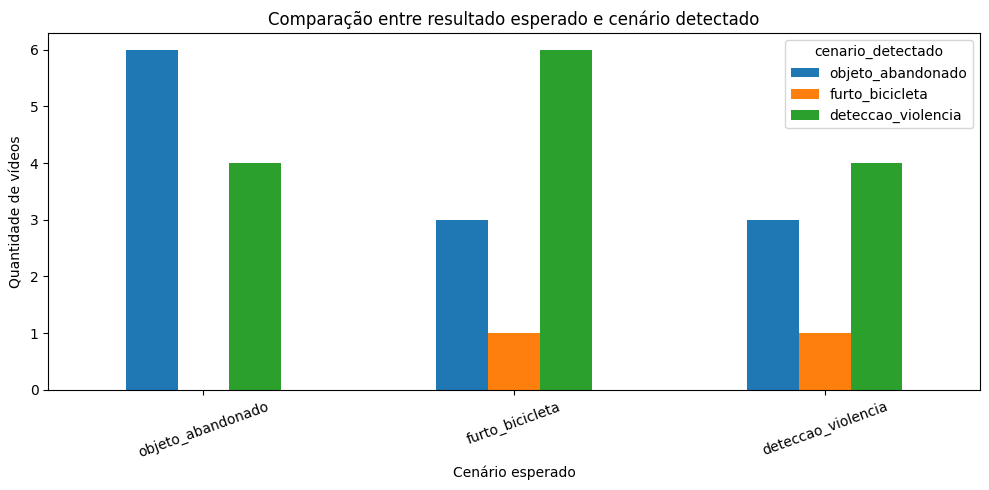

In [37]:

if not df_eventos_consolidados.empty:
    colunas_prioritarias = [
        c for c in [
            "cenario_esperado", "cenario", "video", "frame", "evento", "id_referencia",
            "classe_referencia", "risco", "nivel", "regras_ativadas"
        ] if c in df_eventos_consolidados.columns
    ]
    display(df_eventos_consolidados[colunas_prioritarias].head(20))

    comparacao_video = (
        df_eventos_consolidados.groupby(["cenario_esperado", "video", "cenario"])
        .size()
        .reset_index(name="ocorrencias")
    )

    idx = comparacao_video.groupby(["cenario_esperado", "video"])["ocorrencias"].idxmax()
    comparacao_video_dominante = comparacao_video.loc[idx].reset_index(drop=True)
    comparacao_video_dominante = comparacao_video_dominante.rename(columns={"cenario": "cenario_detectado"})

    tabela_comparacao = pd.crosstab(
        comparacao_video_dominante["cenario_esperado"],
        comparacao_video_dominante["cenario_detectado"],
        dropna=False
    ).reindex(index=CENARIOS_FIXOS, columns=CENARIOS_FIXOS, fill_value=0)

    print("Tabela consolidada — resultado esperado x detectado")
    display(tabela_comparacao)

    tabela_comparacao.plot(kind="bar", figsize=(10, 5))
    plt.title("Comparação entre resultado esperado e cenário detectado")
    plt.xlabel("Cenário esperado")
    plt.ylabel("Quantidade de vídeos")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
else:
    print("Não há eventos consolidados para exibir.")

## 12. Tabela consolidada das detecções

A tabela abaixo exibe as detecções consolidadas com a coluna **cenarios**, indicando os cenários associados à detecção naquele frame. Quando não houver associação com evento, a detecção aparece como `sem_evento`.

In [38]:
if not df_deteccoes_consolidadas.empty:
    colunas_prioritarias = [
        c for c in ["cenario_esperado", "video", "frame", "id", "classe", "cenarios", "centro_x", "centro_y", "largura", "altura"]
        if c in df_deteccoes_consolidadas.columns
    ]
    display(df_deteccoes_consolidadas[colunas_prioritarias].head(20))
else:
    print("Não há detecções consolidadas para exibir.")

,cenario_esperado,video,frame,id,classe,cenarios,centro_x,centro_y,largura,altura
0,objeto_abandonado,01.avi,0,1,person,sem_evento,497.965698,177.600601,35.300171,126.360687
1,objeto_abandonado,01.avi,0,2,person,sem_evento,77.611923,167.757782,36.085148,93.738106
2,objeto_abandonado,01.avi,0,3,person,sem_evento,554.264893,170.797195,26.132690,140.061829
3,objeto_abandonado,01.avi,0,4,person,sem_evento,19.240492,252.862762,38.480984,118.255127
4,objeto_abandonado,01.avi,0,5,handbag,sem_evento,64.078003,289.912323,81.893539,70.091553
5,objeto_abandonado,01.avi,1,1,person,sem_evento,498.097046,177.472855,35.037933,126.062111
6,objeto_abandonado,01.avi,1,2,person,sem_evento,69.402641,167.341339,34.420471,92.875801
7,objeto_abandonado,01.avi,1,3,person,sem_evento,554.408813,170.422058,26.374512,140.052917
8,objeto_abandonado,01.avi,1,4,person,sem_evento,19.397497,253.167450,38.716839,116.820084
9,objeto_abandonado,01.avi,1,5,handbag,sem_evento,64.487595,289.772552,81.710556,70.248428


## 13. Histograma da distribuição de eventos por cenário

Este gráfico distribui a quantidade de eventos detectados em cada cenário no formato de histograma/barra. Os **três cenários sempre aparecem**, inclusive quando algum deles possuir **zero ocorrências**.

,cenario,quantidade_eventos
0,objeto_abandonado,1489
1,furto_bicicleta,68
2,deteccao_violencia,644


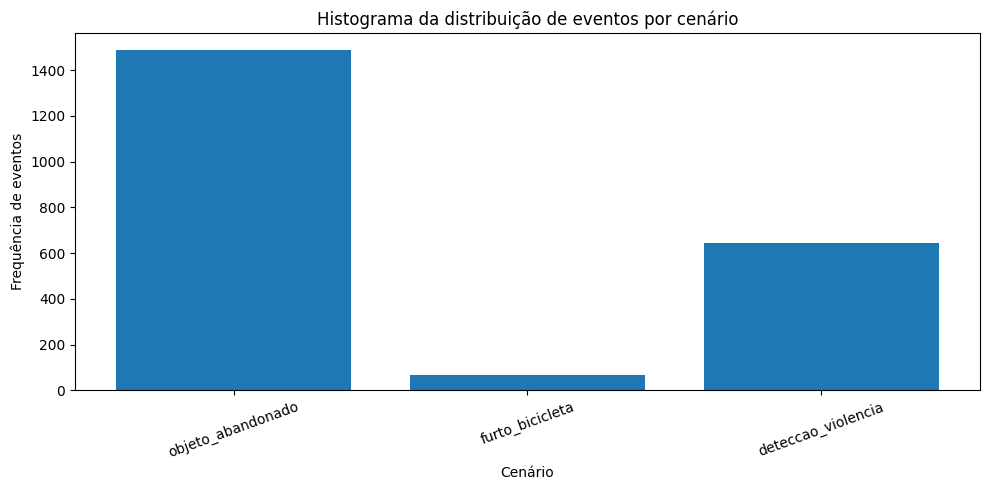

In [39]:

contagem_cenarios = pd.DataFrame({
    "cenario": CENARIOS_FIXOS,
    "quantidade_eventos": [0] * len(CENARIOS_FIXOS)
})

if not df_eventos_consolidados.empty and "cenario" in df_eventos_consolidados.columns:
    contagem_real = (
        df_eventos_consolidados["cenario"]
        .value_counts()
        .reindex(CENARIOS_FIXOS, fill_value=0)
        .rename_axis("cenario")
        .reset_index(name="quantidade_eventos")
    )
    contagem_cenarios = contagem_real.copy()

display(contagem_cenarios)

plt.figure(figsize=(10, 5))
plt.bar(contagem_cenarios["cenario"], contagem_cenarios["quantidade_eventos"])
plt.xlabel("Cenário")
plt.ylabel("Frequência de eventos")
plt.title("Histograma da distribuição de eventos por cenário")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 13A. Análise estatística multivariada (Z-score e PCA)

Esta seção implementa a normalização por **Z-score** e a projeção em **PCA**, conforme recomendado no review, usando variáveis extraídas dos eventos consolidados.

In [40]:

COLUNAS_ANALISE = [
    "tempo_observado",
    "tempo_sem_movimento",
    "distancia_minima_pessoa",
    "distancia_minima_objeto",
    "densidade_pessoas",
    "entropia_trajetoria",
    "mudancas_direcao",
    "aceleracao_media",
    "risco",
    "risco_bayesiano"
]

if not df_eventos_consolidados.empty:
    colunas_existentes = [c for c in COLUNAS_ANALISE if c in df_eventos_consolidados.columns]
    df_analise = df_eventos_consolidados[colunas_existentes + ["cenario"]].copy()
    df_analise = df_analise.replace([np.inf, -np.inf], np.nan).dropna()

    if len(df_analise) >= 3 and len(colunas_existentes) >= 2:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(df_analise[colunas_existentes])

        pca = PCA(n_components=2, random_state=SEED_EXPERIMENTO)
        X_pca = pca.fit_transform(X_scaled)

        df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=df_analise.index)
        df_pca["cenario"] = df_analise["cenario"].values
        df_pca["risco_multivariado"] = np.sqrt(df_pca["PC1"]**2 + df_pca["PC2"]**2)

        print("Variância explicada pelo PCA:")
        for i, var in enumerate(pca.explained_variance_ratio_):
            print(f"PC{i+1}: {var:.2%}")

        display(df_pca.head(20))

        plt.figure(figsize=(8, 6))
        for cenario in sorted(df_pca["cenario"].dropna().unique()):
            subset = df_pca[df_pca["cenario"] == cenario]
            plt.scatter(subset["PC1"], subset["PC2"], label=cenario, alpha=0.7)
        plt.title("Distribuição PCA dos cenários")
        plt.xlabel("Componente Principal 1")
        plt.ylabel("Componente Principal 2")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        df_pca.to_csv(os.path.join(RESULTADOS_PATH, "analise_pca_eventos.csv"), index=False)
    else:
        print("Dados insuficientes para PCA/Z-score.")
else:
    print("Não há eventos consolidados para análise estatística.")


Dados insuficientes para PCA/Z-score.


## 14. Gráfico comparativo: FPS médio por vídeo

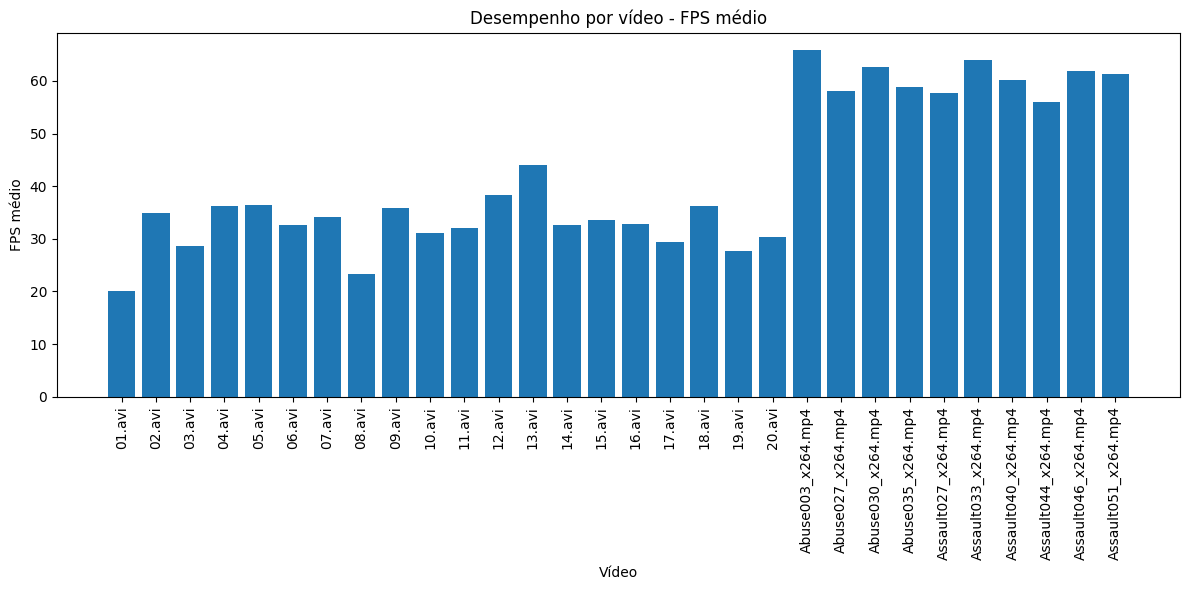

In [41]:
plt.figure(figsize=(12, 6))
plt.bar(df_resumo["video"], df_resumo["fps_medio"])
plt.xticks(rotation=90)
plt.ylabel("FPS médio")
plt.xlabel("Vídeo")
plt.title("Desempenho por vídeo - FPS médio")
plt.tight_layout()
plt.show()

## 14A. Métricas de desempenho de software

Latência média por frame, FPS processado e uso de recursos, conforme solicitado no review.

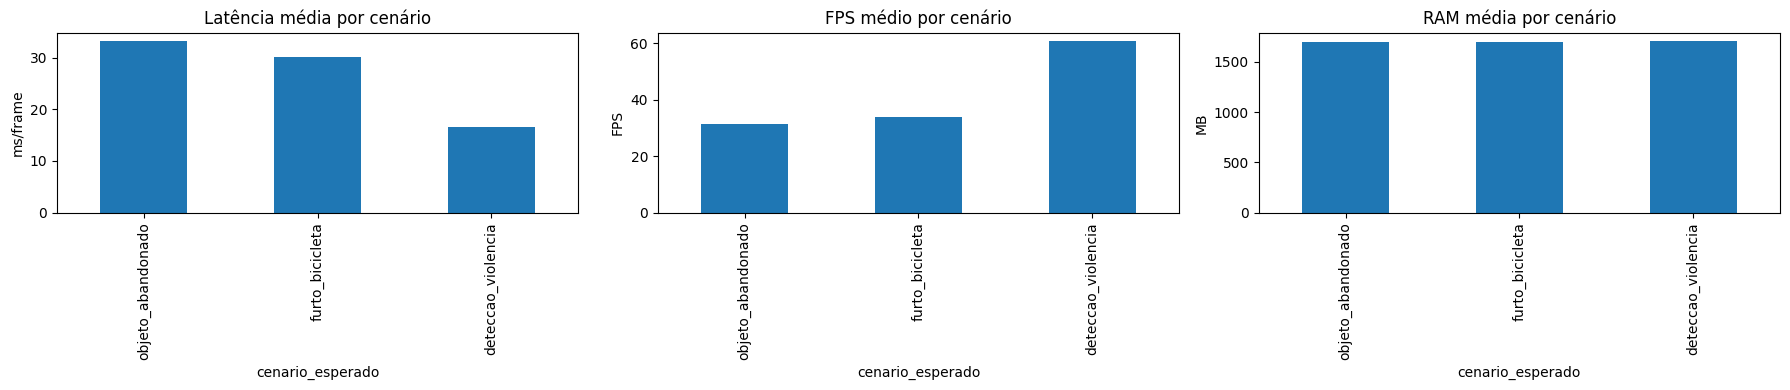

In [42]:

if not df_resumo.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    df_resumo.groupby("cenario_esperado")["latencia_ms_frame"].mean().reindex(CENARIOS_FIXOS).plot(kind="bar", ax=axes[0])
    axes[0].set_title("Latência média por cenário")
    axes[0].set_ylabel("ms/frame")

    df_resumo.groupby("cenario_esperado")["fps_medio"].mean().reindex(CENARIOS_FIXOS).plot(kind="bar", ax=axes[1])
    axes[1].set_title("FPS médio por cenário")
    axes[1].set_ylabel("FPS")

    df_resumo.groupby("cenario_esperado")["ram_mb"].mean().reindex(CENARIOS_FIXOS).plot(kind="bar", ax=axes[2])
    axes[2].set_title("RAM média por cenário")
    axes[2].set_ylabel("MB")

    plt.tight_layout()
    plt.show()
else:
    print("Sem resumo para gerar métricas de desempenho.")


## 15. Gráfico comparativo: detecções totais por vídeo

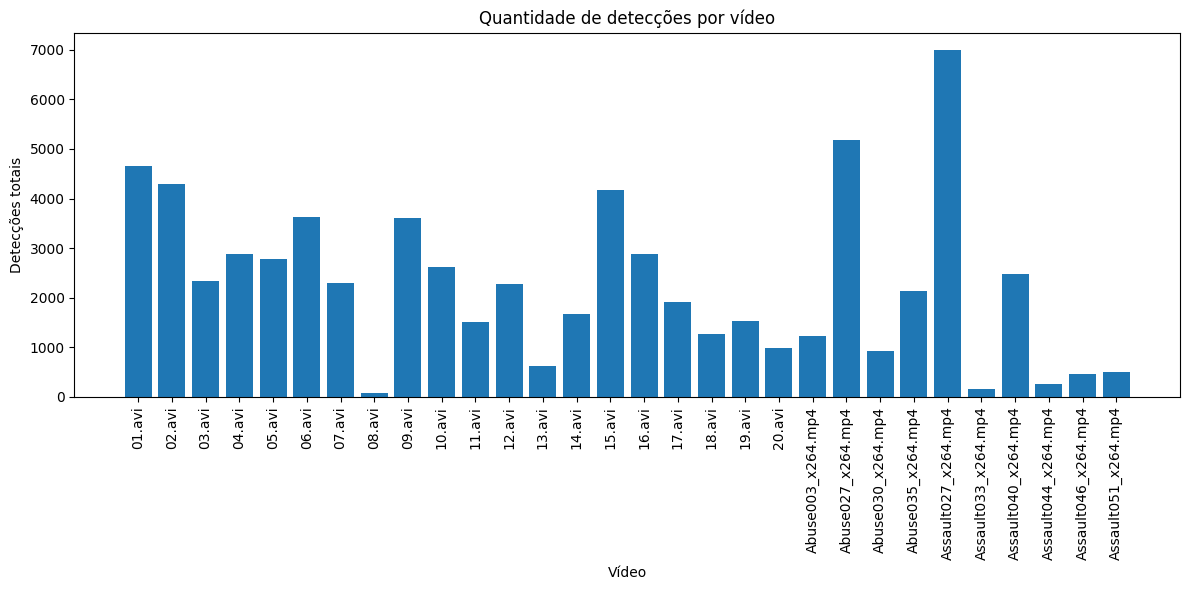

In [43]:
plt.figure(figsize=(12, 6))
plt.bar(df_resumo["video"], df_resumo["deteccoes_totais"])
plt.xticks(rotation=90)
plt.ylabel("Detecções totais")
plt.xlabel("Vídeo")
plt.title("Quantidade de detecções por vídeo")
plt.tight_layout()
plt.show()

## 16. Série temporal do risco agregado de um vídeo

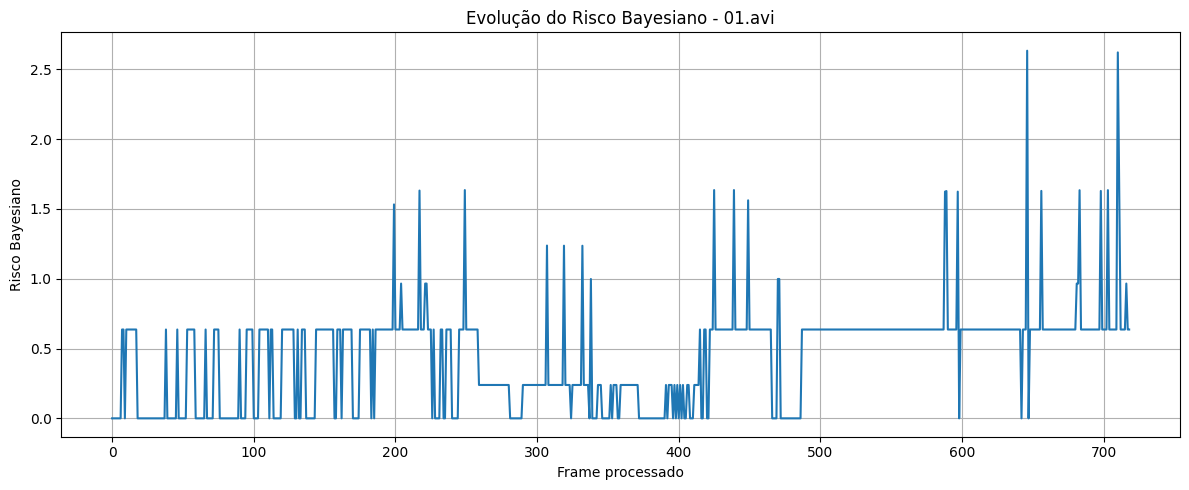

In [44]:

if not df_resumo.empty and series_risco_bayes:
    video_exemplo = df_resumo.sort_values("eventos_totais", ascending=False).iloc[0]["video"]

    plt.figure(figsize=(12, 5))
    plt.plot(series_risco_bayes.get(video_exemplo, []))
    plt.xlabel("Frame processado")
    plt.ylabel("Risco Bayesiano")
    plt.title(f"Evolução do Risco Bayesiano - {video_exemplo}")
    plt.tight_layout()
    plt.grid(True)
    plt.show()
else:
    print("Nenhum dado de risco bayesiano foi gerado para exibição.")


## 17. Análise comparativa conjunta entre os cenários

Os três histogramas individuais foram reunidos em uma análise comparativa única, com mesma escala visual e leitura padronizada para:

- `objeto_abandonado`
- `furto_bicicleta`
- `deteccao_violencia`

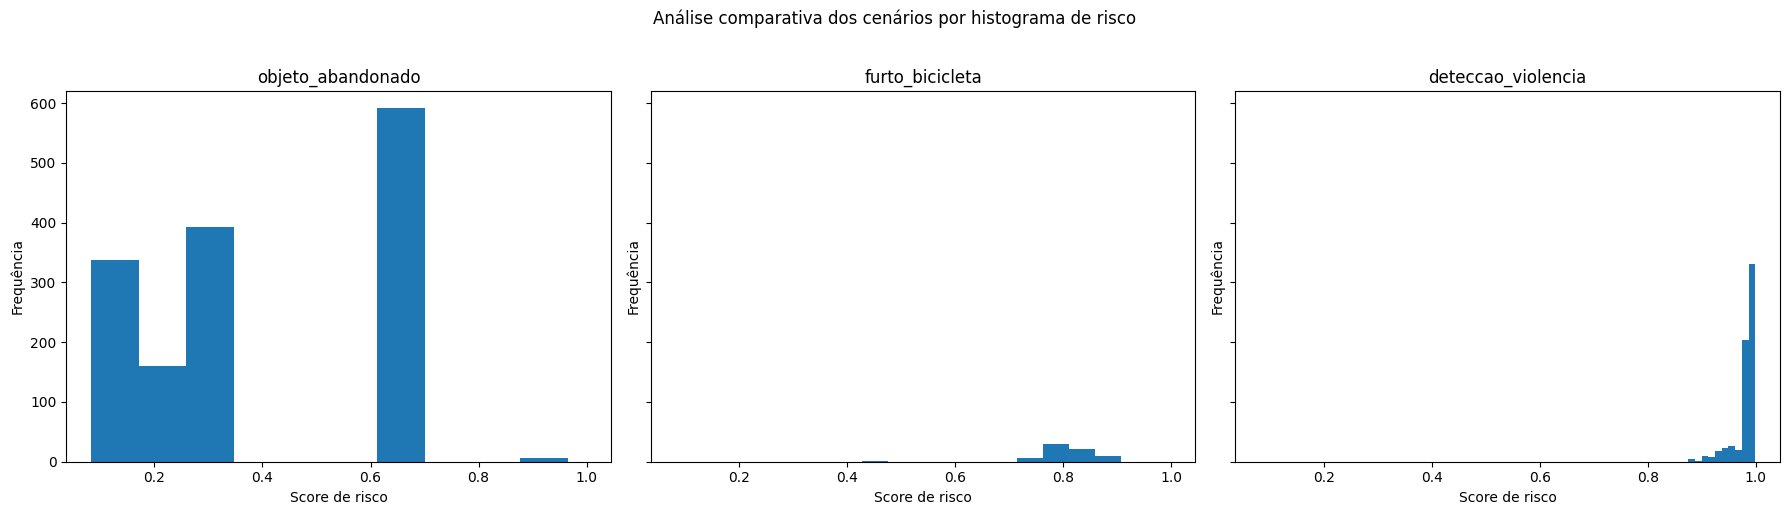

,cenario,ocorrencias,risco_medio,risco_mediano,risco_maximo
0,objeto_abandonado,1489,0.389475,0.333333,0.965517
1,furto_bicicleta,68,0.803932,0.802555,0.906311
2,deteccao_violencia,644,0.981275,0.986939,0.999053


In [45]:

fig, axes = plt.subplots(1, len(CENARIOS_FIXOS), figsize=(6 * len(CENARIOS_FIXOS), 5), sharex=True, sharey=True)

if len(CENARIOS_FIXOS) == 1:
    axes = [axes]

for ax, cenario in zip(axes, CENARIOS_FIXOS):
    if not df_eventos_consolidados.empty and "cenario" in df_eventos_consolidados.columns:
        df_tmp = df_eventos_consolidados[df_eventos_consolidados["cenario"] == cenario].copy()
    else:
        df_tmp = pd.DataFrame()

    if not df_tmp.empty and "risco" in df_tmp.columns:
        ax.hist(df_tmp["risco"].dropna(), bins=10)
    else:
        ax.text(0.5, 0.5, "Sem ocorrências", ha="center", va="center", transform=ax.transAxes)

    ax.set_title(f"{cenario}")
    ax.set_xlabel("Score de risco")
    ax.set_ylabel("Frequência")

fig.suptitle("Análise comparativa dos cenários por histograma de risco", y=1.02)
plt.tight_layout()
plt.show()

if not df_eventos_consolidados.empty and "cenario" in df_eventos_consolidados.columns:
    resumo_comparativo = (
        df_eventos_consolidados.groupby("cenario")
        .agg(
            ocorrencias=("cenario", "size"),
            risco_medio=("risco", "mean"),
            risco_mediano=("risco", "median"),
            risco_maximo=("risco", "max")
        )
        .reindex(CENARIOS_FIXOS, fill_value=0)
        .reset_index()
    )
else:
    resumo_comparativo = pd.DataFrame({
        "cenario": CENARIOS_FIXOS,
        "ocorrencias": [0] * len(CENARIOS_FIXOS),
        "risco_medio": [0.0] * len(CENARIOS_FIXOS),
        "risco_mediano": [0.0] * len(CENARIOS_FIXOS),
        "risco_maximo": [0.0] * len(CENARIOS_FIXOS),
    })

display(resumo_comparativo)

## 18. Tabela comparativa final

Resumo comparativo dos vídeos processados no modo selecionado (`dataset_cenarios` ou `datasets` públicos).


In [46]:
if not df_resumo.empty:
    ordenar_por = [c for c in ["cenario_esperado", "eventos_totais", "risco_medio_frame"] if c in df_resumo.columns]
    tabela_comparativa_final = df_resumo.sort_values(
        ordenar_por,
        ascending=[True, False, False] if len(ordenar_por) == 3 else [False] * len(ordenar_por)
    )
    display(tabela_comparativa_final)
else:
    print("Não há resumo consolidado para gerar a tabela comparativa final.")

,video,frames_lidos,frames_processados,frame_stride,deteccoes_totais,eventos_totais,eventos_objeto_abandonado,eventos_furto_bicicleta,eventos_deteccao_violencia,risco_medio_frame,risco_bayes_medio_frame,tempo_medio_frame_seg,fps_medio,tempo_total_seg,latencia_ms_frame,ram_mb,gpu_mb,cenario_esperado
21,Abuse027_x264.mp4,4372,2186,2,5171,100,61,0,39,0.024761,0.024761,0.017192,58.165419,39.412,17.192,1702.15,50.56,deteccao_violencia
24,Assault027_x264.mp4,6949,3474,2,6994,94,15,4,75,0.023427,0.023427,0.017309,57.771968,63.180,17.309,1703.27,50.56,deteccao_violencia
23,Abuse035_x264.mp4,2651,1325,2,2134,49,25,0,24,0.022407,0.022407,0.016998,58.828816,23.833,16.998,1702.15,50.56,deteccao_violencia
20,Abuse003_x264.mp4,3699,1849,2,1223,24,11,0,13,0.008922,0.008922,0.015189,65.835490,29.713,15.189,1701.91,50.56,deteccao_violencia
29,Assault051_x264.mp4,601,300,2,503,9,0,8,1,0.025194,0.025194,0.016312,61.303477,5.156,16.312,1704.77,50.56,deteccao_violencia
25,Assault033_x264.mp4,1278,639,2,163,7,7,0,0,0.003652,0.003652,0.015646,63.914864,10.710,15.646,1704.77,50.56,deteccao_violencia
27,Assault044_x264.mp4,764,382,2,262,3,0,0,3,0.007826,0.007826,0.017849,56.024450,7.247,17.849,1704.77,50.56,deteccao_violencia
28,Assault046_x264.mp4,952,476,2,464,1,0,0,1,0.002092,0.002092,0.016175,61.821905,8.062,16.175,1704.77,50.56,deteccao_violencia
22,Abuse030_x264.mp4,1544,772,2,932,0,0,0,0,0.000000,0.000000,0.015987,62.550350,13.044,15.987,1702.15,50.56,deteccao_violencia
26,Assault040_x264.mp4,3779,1889,2,2482,0,0,0,0,0.000000,0.000000,0.016646,60.073909,32.941,16.646,1704.77,50.56,deteccao_violencia


## 19. Consolidação final dos eventos por vídeo e cenário

In [47]:
if not df_eventos_consolidados.empty:
    agrupadores = [c for c in ["cenario_esperado", "video", "cenario"] if c in df_eventos_consolidados.columns]
    tabela_final = (
        df_eventos_consolidados.groupby(agrupadores)
        .agg(
            ocorrencias=("cenario", "size"),
            risco_medio=("risco", "mean"),
            risco_maximo=("risco", "max")
        )
        .reset_index()
    )

    categorias = pd.CategoricalDtype(categories=CENARIOS_FIXOS, ordered=True)
    if "cenario" in tabela_final.columns:
        tabela_final["cenario"] = tabela_final["cenario"].astype(categorias)

    ordenar_por = [c for c in ["cenario_esperado", "cenario", "ocorrencias", "risco_medio"] if c in tabela_final.columns]
    asc = []
    for c in ordenar_por:
        if c in ["cenario_esperado", "cenario"]:
            asc.append(True)
        else:
            asc.append(False)
    tabela_final = tabela_final.sort_values(ordenar_por, ascending=asc)

    display(tabela_final)
else:
    print("Não há eventos consolidados para gerar a tabela final por vídeo e cenário.")

,cenario_esperado,video,cenario,ocorrencias,risco_medio,risco_maximo
3,deteccao_violencia,Abuse027_x264.mp4,objeto_abandonado,61,0.263388,0.333333
5,deteccao_violencia,Abuse035_x264.mp4,objeto_abandonado,25,0.242980,0.333333
8,deteccao_violencia,Assault027_x264.mp4,objeto_abandonado,15,0.333333,0.333333
1,deteccao_violencia,Abuse003_x264.mp4,objeto_abandonado,11,0.333333,0.333333
9,deteccao_violencia,Assault033_x264.mp4,objeto_abandonado,7,0.333333,0.333333
13,deteccao_violencia,Assault051_x264.mp4,furto_bicicleta,8,0.824956,0.906311
7,deteccao_violencia,Assault027_x264.mp4,furto_bicicleta,4,0.786394,0.808783
6,deteccao_violencia,Assault027_x264.mp4,deteccao_violencia,75,0.976545,0.998436
2,deteccao_violencia,Abuse027_x264.mp4,deteccao_violencia,39,0.975893,0.990223
4,deteccao_violencia,Abuse035_x264.mp4,deteccao_violencia,24,0.983954,0.998715


## 20. Métricas de classificação para violência (Matriz de Confusão)

Nesta seção, a avaliação é feita em nível de **vídeo**:

- **Classe positiva (violência real):** `cenario_esperado == "deteccao_violencia"`
- **Predição positiva:** existe pelo menos um evento detectado com `cenario == "deteccao_violencia"` no vídeo

Métricas calculadas:

- **Precision** $= \frac{TP}{TP+FP}$
- **Recall (Sensitivity)** $= \frac{TP}{TP+FN}$
- **F1-Score**
- **F-beta** com $\beta = 2$ (prioriza Recall)

A matriz de confusão reporta `TP`, `FP`, `FN` e `TN` para o cenário de violência.

Matriz de confusao - classe positiva: deteccao_violencia


/tmp/ipykernel_9243/2616935914.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_base_metricas["video"].map(pred_violencia_por_video).fillna(False).astype(bool)


,Predito: Violencia,Predito: Nao Violencia
Real: Violencia,7,3
Real: Nao Violencia,20,0


Metricas de classificacao


,metrica,valor
0,Precision,0.259259
1,Recall,0.700000
2,F1-Score,0.378378
3,F-beta (beta=2),0.522388
4,TP,7.000000
5,FP,20.000000
6,FN,3.000000
7,TN,0.000000


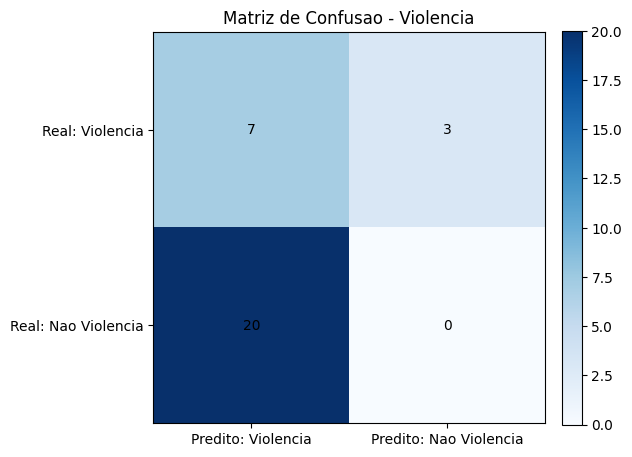

In [48]:
beta = 2.0

# Base de verdade em nivel de video.
if not df_resumo.empty and {"video", "cenario_esperado"}.issubset(df_resumo.columns):
    df_base_metricas = df_resumo[["video", "cenario_esperado"]].drop_duplicates().copy()
elif not df_eventos_consolidados.empty and {"video", "cenario_esperado"}.issubset(df_eventos_consolidados.columns):
    df_base_metricas = df_eventos_consolidados[["video", "cenario_esperado"]].drop_duplicates().copy()
else:
    df_base_metricas = pd.DataFrame(columns=["video", "cenario_esperado"])

if not df_base_metricas.empty:
    df_base_metricas["real_violencia"] = df_base_metricas["cenario_esperado"] == "deteccao_violencia"

    if not df_eventos_consolidados.empty and {"video", "cenario"}.issubset(df_eventos_consolidados.columns):
        pred_violencia_por_video = (
            df_eventos_consolidados.assign(pred_violencia=df_eventos_consolidados["cenario"] == "deteccao_violencia")
            .groupby("video")["pred_violencia"]
            .max()
        )
    else:
        pred_violencia_por_video = pd.Series(dtype=bool)

    df_base_metricas["pred_violencia"] = (
        df_base_metricas["video"].map(pred_violencia_por_video).fillna(False).astype(bool)
    )

    tp = int(((df_base_metricas["real_violencia"] == True) & (df_base_metricas["pred_violencia"] == True)).sum())
    fn = int(((df_base_metricas["real_violencia"] == True) & (df_base_metricas["pred_violencia"] == False)).sum())
    fp = int(((df_base_metricas["real_violencia"] == False) & (df_base_metricas["pred_violencia"] == True)).sum())
    tn = int(((df_base_metricas["real_violencia"] == False) & (df_base_metricas["pred_violencia"] == False)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    fbeta = (
        (1 + beta**2) * precision * recall / ((beta**2) * precision + recall)
        if ((beta**2) * precision + recall) > 0
        else 0.0
    )

    matriz_confusao = pd.DataFrame(
        [[tp, fn], [fp, tn]],
        index=["Real: Violencia", "Real: Nao Violencia"],
        columns=["Predito: Violencia", "Predito: Nao Violencia"]
    )

    tabela_metricas = pd.DataFrame([
        {"metrica": "Precision", "valor": precision},
        {"metrica": "Recall", "valor": recall},
        {"metrica": "F1-Score", "valor": f1},
        {"metrica": f"F-beta (beta={int(beta)})", "valor": fbeta},
        {"metrica": "TP", "valor": tp},
        {"metrica": "FP", "valor": fp},
        {"metrica": "FN", "valor": fn},
        {"metrica": "TN", "valor": tn}
    ])

    print("Matriz de confusao - classe positiva: deteccao_violencia")
    display(matriz_confusao)

    print("Metricas de classificacao")
    display(tabela_metricas)

    # Visualizacao da matriz de confusao.
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(matriz_confusao.values, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(matriz_confusao.columns)
    ax.set_yticklabels(matriz_confusao.index)
    ax.set_title("Matriz de Confusao - Violencia")

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(matriz_confusao.values[i, j]), ha="center", va="center", color="black")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
else:
    print("Nao ha dados suficientes para calcular as metricas de classificacao.")

## 21. Métricas de localização e detecção do YOLOv26

Esta seção valida a qualidade da detecção usada pelas regras baseadas em `IoU` e proximidade.

Métricas-alvo:

- **mAP@0.5**: precisão média com critério mínimo de sobreposição de 50%.
- **mAP@0.5:0.95**: métrica mais rigorosa, média em múltiplos limiares de IoU.
- **Localization Error**: erro médio de localização, calculado como $1 - IoU$ entre predição e rótulo real (mesma classe), além da taxa de caixas mal localizadas.

Observação:

- Para calcular mAP e erro de localização com validade estatística, é necessário ter **dataset de validação com anotações** (arquivo YAML + labels).

In [49]:
from pathlib import Path


def _buscar_yaml_dataset(dataset_base):
    base = Path(dataset_base)
    candidatos = []

    # Candidatos comuns de arquivo de configuracao YOLO.
    candidatos.extend([
        base / "data.yaml",
        base / "dataset.yaml",
        base / "yolo.yaml",
        base.parent / "data.yaml",
        base.parent / "dataset.yaml",
        base.parent / "yolo.yaml"
    ])

    for c in candidatos:
        if c.exists():
            return c

    # Busca leve recursiva na pasta base.
    for nome in ["data.yaml", "dataset.yaml", "yolo.yaml"]:
        achados = list(base.rglob(nome))
        if achados:
            return achados[0]

    return None


def _carregar_yaml(path_yaml):
    try:
        import yaml
    except Exception:
        return None

    with open(path_yaml, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)


def _resolver_pasta_val(yaml_dict, path_yaml):
    if yaml_dict is None or "val" not in yaml_dict:
        return None

    raiz = Path(yaml_dict.get("path", path_yaml.parent))
    val = Path(yaml_dict["val"])

    if val.is_absolute():
        return val

    return (raiz / val).resolve()


def _labels_para_imagem(img_path):
    # Conversao padrao YOLO: .../images/xxx.jpg -> .../labels/xxx.txt
    p = Path(img_path)
    partes = list(p.parts)

    if "images" in partes:
        i = partes.index("images")
        partes[i] = "labels"
        rotulo = Path(*partes).with_suffix(".txt")
    else:
        rotulo = p.with_suffix(".txt")

    return rotulo


def _xywhn_para_xyxy(b, w, h):
    # b = [xc, yc, bw, bh] normalizado
    xc, yc, bw, bh = b
    x1 = (xc - bw / 2.0) * w
    y1 = (yc - bh / 2.0) * h
    x2 = (xc + bw / 2.0) * w
    y2 = (yc + bh / 2.0) * h
    return np.array([x1, y1, x2, y2], dtype=float)


def _iou_xyxy(a, b):
    x1 = max(a[0], b[0])
    y1 = max(a[1], b[1])
    x2 = min(a[2], b[2])
    y2 = min(a[3], b[3])

    iw = max(0.0, x2 - x1)
    ih = max(0.0, y2 - y1)
    inter = iw * ih

    area_a = max(0.0, a[2] - a[0]) * max(0.0, a[3] - a[1])
    area_b = max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])
    un = area_a + area_b - inter

    if un <= 0:
        return 0.0
    return float(inter / un)


# 1) mAP do YOLO (via rotina de validacao do Ultralytics)
yaml_path = _buscar_yaml_dataset(CENARIOS_PATH)

if yaml_path is None:
    print("Nao foi encontrado arquivo YAML de dataset. mAP e erro de localizacao nao podem ser calculados com GT.")
else:
    print(f"YAML encontrado: {yaml_path}")

    try:
        resultados_val = modelo_yolo.val(data=str(yaml_path), split="val", verbose=False)
        map50 = float(resultados_val.box.map50)
        map50_95 = float(resultados_val.box.map)

        tabela_map = pd.DataFrame([
            {"metrica": "mAP@0.5", "valor": map50},
            {"metrica": "mAP@0.5:0.95", "valor": map50_95}
        ])

        print("Metricas de deteccao do YOLOv26")
        display(tabela_map)
    except Exception as e:
        print(f"Falha ao calcular mAP via val(): {e}")
        map50 = np.nan
        map50_95 = np.nan

    # 2) Localization Error por IoU (predicao vs GT da mesma classe)
    yaml_dict = _carregar_yaml(yaml_path)
    pasta_val = _resolver_pasta_val(yaml_dict, yaml_path)

    if pasta_val is None or (not pasta_val.exists()):
        print("Nao foi possivel resolver a pasta de validacao no YAML para calcular Localization Error.")
    else:
        exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
        imagens = [p for p in pasta_val.rglob("*") if p.suffix.lower() in exts]

        max_imagens_avaliacao = 200
        imagens = imagens[:max_imagens_avaliacao]

        ious_match = []
        total_predicoes_com_classe = 0
        caixas_mal_localizadas = 0
        iou_limiar_localizacao = 0.5

        # Analise direcionada a falso IoU entre pessoas (regra de briga).
        casos_iou_pessoa_suspeito = 0

        for img_path in imagens:
            rot_path = _labels_para_imagem(img_path)
            if not rot_path.exists():
                continue

            img = cv2.imread(str(img_path))
            if img is None:
                continue

            h, w = img.shape[:2]

            gt_boxes = []
            gt_cls = []
            with open(rot_path, "r", encoding="utf-8") as f:
                for linha in f:
                    p = linha.strip().split()
                    if len(p) != 5:
                        continue
                    c = int(float(p[0]))
                    xc, yc, bw, bh = map(float, p[1:])
                    gt_boxes.append(_xywhn_para_xyxy([xc, yc, bw, bh], w, h))
                    gt_cls.append(c)

            if len(gt_boxes) == 0:
                continue

            try:
                pred = modelo_yolo.predict(source=str(img_path), verbose=False, conf=0.25, iou=0.7)[0]
            except Exception:
                continue

            if pred.boxes is None or len(pred.boxes) == 0:
                continue

            pred_xyxy = pred.boxes.xyxy.cpu().numpy()
            pred_cls = pred.boxes.cls.cpu().numpy().astype(int)

            for b_pred, c_pred in zip(pred_xyxy, pred_cls):
                candidatos = [i for i, c in enumerate(gt_cls) if c == c_pred]
                if len(candidatos) == 0:
                    continue

                total_predicoes_com_classe += 1
                melhor_iou = max(_iou_xyxy(b_pred, gt_boxes[i]) for i in candidatos)
                ious_match.append(melhor_iou)

                if melhor_iou < iou_limiar_localizacao:
                    caixas_mal_localizadas += 1

                # Classe YOLO para pessoa costuma ser 0 (fallback por nome do modelo).
                eh_pessoa = (c_pred == 0)
                if hasattr(modelo_yolo, "names") and isinstance(modelo_yolo.names, dict):
                    nome = modelo_yolo.names.get(int(c_pred), "")
                    eh_pessoa = (str(nome).lower() == "person")

                if eh_pessoa and (0.1 <= melhor_iou < 0.5):
                    casos_iou_pessoa_suspeito += 1

        if len(ious_match) == 0:
            print("Nao houve pares suficientes predicao-GT para calcular Localization Error.")
        else:
            localization_error = float(np.mean([1.0 - x for x in ious_match]))
            taxa_mal_localizada = float(caixas_mal_localizadas / max(total_predicoes_com_classe, 1))

            tabela_loc = pd.DataFrame([
                {"metrica": "Localization Error medio (1 - IoU)", "valor": localization_error},
                {"metrica": "Taxa de caixas mal localizadas (IoU < 0.5)", "valor": taxa_mal_localizada},
                {"metrica": "Casos suspeitos de IoU entre pessoas (0.1 <= IoU < 0.5)", "valor": int(casos_iou_pessoa_suspeito)}
            ])

            print("Metricas de localizacao")
            display(tabela_loc)

            plt.figure(figsize=(8, 4))
            plt.hist(ious_match, bins=20)
            plt.axvline(0.5, color="red", linestyle="--", label="IoU = 0.5")
            plt.title("Distribuicao de IoU (predicoes x GT da mesma classe)")
            plt.xlabel("IoU")
            plt.ylabel("Frequencia")
            plt.legend()
            plt.tight_layout()
            plt.show()

Nao foi encontrado arquivo YAML de dataset. mAP e erro de localizacao nao podem ser calculados com GT.


In [50]:
print(f"O sistema buscou pelo arquivo YAML do dataset nos seguintes locais (e subdiretórios):")
print(f"Base do CENARIOS_PATH: {CENARIOS_PATH}")
print("Nomes de arquivo esperados: data.yaml, dataset.yaml, yolo.yaml")

O sistema buscou pelo arquivo YAML do dataset nos seguintes locais (e subdiretórios):
Base do CENARIOS_PATH: /content/drive/MyDrive/TCC_ECAI_2026/dataset_cenarios
Nomes de arquivo esperados: data.yaml, dataset.yaml, yolo.yaml


## 22. Métricas de desempenho temporal (análise de vídeo)

Nesta seção, a avaliação é orientada a **evento** de violência, não apenas a frames isolados.

Métricas calculadas:

- **TTA (Time to Alarm):** tempo entre o início visual da violência e o primeiro alerta do sistema.
- **MTBFA (Mean Time Between False Alarms):** horas de vídeo normal processadas até ocorrer um alarme falso.
- **Event-based Recall:** fração de eventos reais de violência que foram capturados pelo detector.

Importante:

- Para TTA e Event-based Recall com validade experimental, preencha as anotações temporais dos eventos reais em `ANOTACOES_EVENTOS` (início/fim em segundos por vídeo).

In [51]:
# -----------------------------
# Configuracao de avaliacao temporal
# -----------------------------
# Preencha com anotacoes reais de violencia por video.
# Exemplo:
# ANOTACOES_EVENTOS = {
#     "video_01.mp4": [{"inicio_s": 12.3, "fim_s": 41.8}],
#     "video_02.mp4": [{"inicio_s": 7.0, "fim_s": 19.5}, {"inicio_s": 55.0, "fim_s": 63.0}]
# }
ANOTACOES_EVENTOS = {}

# Cobertura minima da janela real para considerar evento capturado.
COBERTURA_MIN_EVENTO = 0.20

# Agrupamento de alarmes consecutivos para contar eventos de alarme.
GAP_MAX_ALARME_SEG = 1.0


def _obter_fps_video(row):
    fps = float(row.get("fps_medio", 0.0))
    if np.isfinite(fps) and fps > 1e-6:
        return fps
    return np.nan


def _agrupar_frames_em_eventos(frames, gap_max_frames):
    if frames is None or len(frames) == 0:
        return []

    frames_sorted = sorted(set(int(f) for f in frames))
    eventos = []
    ini = frames_sorted[0]
    fim = frames_sorted[0]

    for f in frames_sorted[1:]:
        if (f - fim) <= gap_max_frames:
            fim = f
        else:
            eventos.append((ini, fim))
            ini, fim = f, f

    eventos.append((ini, fim))
    return eventos


# Base de frames detectados para violencia por video
if not df_eventos_consolidados.empty and {"video", "frame", "cenario"}.issubset(df_eventos_consolidados.columns):
    df_viol = df_eventos_consolidados[df_eventos_consolidados["cenario"] == "deteccao_violencia"].copy()
else:
    df_viol = pd.DataFrame(columns=["video", "frame", "cenario"])

frames_viol_por_video = {
    v: sorted(g["frame"].dropna().astype(int).tolist())
    for v, g in df_viol.groupby("video")
} if not df_viol.empty else {}

# Tabela auxiliar de FPS/duracao por video
if not df_resumo.empty and {"video", "frames", "fps_medio", "cenario_esperado"}.issubset(df_resumo.columns):
    df_meta = df_resumo[["video", "frames", "fps_medio", "cenario_esperado"]].drop_duplicates().copy()
else:
    df_meta = pd.DataFrame(columns=["video", "frames", "fps_medio", "cenario_esperado"])

# -----------------------------
# 1) TTA e Event-based Recall
# -----------------------------
registros_evento = []

if len(ANOTACOES_EVENTOS) == 0:
    print("Aviso: ANOTACOES_EVENTOS esta vazio. TTA e Event-based Recall exigem anotacao temporal real.")

for _, row in df_meta.iterrows():
    video = row["video"]
    fps = _obter_fps_video(row)

    if not np.isfinite(fps) or fps <= 0:
        continue

    eventos_gt = ANOTACOES_EVENTOS.get(video, [])
    if len(eventos_gt) == 0:
        continue

    frames_det = frames_viol_por_video.get(video, [])

    for idx_evt, evt in enumerate(eventos_gt, start=1):
        ini_s = float(evt.get("inicio_s", np.nan))
        fim_s = float(evt.get("fim_s", np.nan))

        if not np.isfinite(ini_s) or not np.isfinite(fim_s) or fim_s <= ini_s:
            continue

        ini_f = int(round(ini_s * fps))
        fim_f = int(round(fim_s * fps))

        det_no_evento = [f for f in frames_det if ini_f <= f <= fim_f]
        dur_frames = max(fim_f - ini_f + 1, 1)
        cobertura = len(set(det_no_evento)) / dur_frames

        if len(det_no_evento) > 0:
            primeiro_alerta_f = min(det_no_evento)
            tta_s = max((primeiro_alerta_f - ini_f) / fps, 0.0)
        else:
            primeiro_alerta_f = np.nan
            tta_s = np.nan

        evento_capturado = bool((len(det_no_evento) > 0) and (cobertura >= COBERTURA_MIN_EVENTO or len(det_no_evento) >= 1))

        registros_evento.append({
            "video": video,
            "evento_id": idx_evt,
            "inicio_evento_s": ini_s,
            "fim_evento_s": fim_s,
            "fps": fps,
            "cobertura_evento": cobertura,
            "primeiro_alerta_frame": primeiro_alerta_f,
            "tta_s": tta_s,
            "evento_capturado": evento_capturado
        })

df_eventos_temporais = pd.DataFrame(registros_evento)

if not df_eventos_temporais.empty:
    event_recall = float(df_eventos_temporais["evento_capturado"].mean())
    tta_validos = df_eventos_temporais.loc[df_eventos_temporais["evento_capturado"], "tta_s"].dropna()

    tta_medio = float(tta_validos.mean()) if len(tta_validos) > 0 else np.nan
    tta_mediano = float(tta_validos.median()) if len(tta_validos) > 0 else np.nan

    tabela_temporal_eventos = pd.DataFrame([
        {"metrica": "Event-based Recall", "valor": event_recall},
        {"metrica": "TTA medio (s)", "valor": tta_medio},
        {"metrica": "TTA mediano (s)", "valor": tta_mediano},
        {"metrica": "Eventos reais avaliados", "valor": int(len(df_eventos_temporais))}
    ])

    print("Metricas temporais orientadas a evento")
    display(tabela_temporal_eventos)
    display(df_eventos_temporais)
else:
    print("Sem anotacoes temporais validas para calcular TTA e Event-based Recall.")

# -----------------------------
# 2) MTBFA (videos normais)
# -----------------------------
if not df_meta.empty:
    df_normais = df_meta[df_meta["cenario_esperado"] != "deteccao_violencia"].copy()

    total_horas_normais = 0.0
    total_alarmes_falsos = 0

    for _, row in df_normais.iterrows():
        video = row["video"]
        fps = _obter_fps_video(row)
        frames_total = float(row.get("frames", 0.0))

        if np.isfinite(fps) and fps > 0 and np.isfinite(frames_total) and frames_total > 0:
            total_horas_normais += (frames_total / fps) / 3600.0

        frames_det = frames_viol_por_video.get(video, [])
        if len(frames_det) == 0 or (not np.isfinite(fps)) or fps <= 0:
            continue

        gap_max_frames = int(round(GAP_MAX_ALARME_SEG * fps))
        eventos_alarme = _agrupar_frames_em_eventos(frames_det, gap_max_frames)
        total_alarmes_falsos += len(eventos_alarme)

    if total_alarmes_falsos > 0:
        mtbfa_horas = total_horas_normais / total_alarmes_falsos
    else:
        mtbfa_horas = np.inf

    tabela_mtbfa = pd.DataFrame([
        {"metrica": "Horas totais de video normal", "valor": total_horas_normais},
        {"metrica": "Total de alarmes falsos (eventos)", "valor": int(total_alarmes_falsos)},
        {"metrica": "MTBFA (horas)", "valor": mtbfa_horas}
    ])

    print("MTBFA - Mean Time Between False Alarms")
    display(tabela_mtbfa)
else:
    print("Sem metadados de video para calcular MTBFA.")

Aviso: ANOTACOES_EVENTOS esta vazio. TTA e Event-based Recall exigem anotacao temporal real.
Sem anotacoes temporais validas para calcular TTA e Event-based Recall.
Sem metadados de video para calcular MTBFA.
